# Recoverability-Constrained Operational Temporal Geometry

**A minimal reproducible computational notebook**

This notebook explores whether recovery-limited systems evolving under the same external temporal progression can generate distinct operational temporal structures due solely to heterogeneous internal recoverability constraints.

The framework is operational and dynamical. It does **not** introduce relativistic metrics, physical spacetime curvature, Lorentz invariance, or observer-dependent coordinate transformations.

Core outputs generated by this notebook:

- operational internal time divergence
- operational temporal rate and freezing intervals
- future accessibility phase diagrams
- stochastic accessibility fragmentation
- percolation-like degradation of accessibility coherence
- homogeneous vs heterogeneous controls
- temporal accessibility cone visualizations

## 0. Reproducibility setup

This version is independent of Google Drive. It uses only local relative folders created in the current working directory:

- `data/`
- `figures/`
- `outputs/`
- `publication_package/`

No external input CSV files are required to run the notebook. All tables and figures are regenerated from the model.

In [1]:
# ==========================================
# 0. SETUP — DRIVE-INDEPENDENT
# ==========================================

from pathlib import Path
from datetime import datetime
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import networkx as nx

# Project root: current working directory
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLES_FINAL_DIR = PROJECT_ROOT / "tables_final"
FIGURES_FINAL_DIR = PROJECT_ROOT / "figures_final"
PUBLICATION_DIR = PROJECT_ROOT / "publication_package"

for folder in [DATA_DIR, FIG_DIR, OUTPUT_DIR, TABLES_FINAL_DIR, FIGURES_FINAL_DIR, PUBLICATION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

(PUBLICATION_DIR / "figures").mkdir(exist_ok=True)
(PUBLICATION_DIR / "tables").mkdir(exist_ok=True)
(PUBLICATION_DIR / "drafts").mkdir(exist_ok=True)

# Global plotting defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: /content
DATA_DIR: /content/data
FIG_DIR: /content/figures


## 1. Minimal recovery-limited dynamics

We model a scalar operational state variable \(v(t)\) governed by recovery toward baseline and transient external forcing:

\[
\frac{dv}{dt}=\frac{1-v}{\tau_r}-u(t-\Delta)
\]

where \(\tau_r\) is the intrinsic recovery timescale and \(\Delta\) is an optional delay. External perturbations are modeled as Gaussian pulses with controlled total load (`AUC`) and duration (`sigma`).

In [2]:
# ==========================================
# 1. CORE MODEL FUNCTIONS
# ==========================================

def gaussian_pulse(t, auc=1.0, sigma=5.0, t0=50.0):
    """Gaussian forcing pulse normalized by total load AUC."""
    return (auc / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((t - t0) / sigma) ** 2)


def simulate_observer(
    auc=1.0,
    sigma=5.0,
    tau_r=20.0,
    delay=0.0,
    t0=50.0,
    T=200.0,
    dt=0.05,
    v_init=1.0,
    v_collapse=0.35,
    v_return=0.90,
    obs_window=200.0,
):
    """Single-pulse recovery-limited trajectory."""
    t = np.arange(0, T + dt, dt)
    v = np.zeros_like(t)
    v[0] = v_init

    for k in range(1, len(t)):
        effective_t = t[k - 1] - delay
        E = gaussian_pulse(effective_t, auc=auc, sigma=sigma, t0=t0)
        dv = ((1 - v[k - 1]) / tau_r) - E
        v[k] = v[k - 1] + dv * dt

    v_min = float(np.min(v))
    collapsed = bool(v_min < v_collapse)

    after_pulse = t > (t0 + 2 * sigma + delay)
    returned_indices = np.where((after_pulse) & (v >= v_return))[0]

    if len(returned_indices) > 0:
        t_return = float(t[returned_indices[0]])
        recovered = bool(t_return <= obs_window)
    else:
        t_return = np.nan
        recovered = False

    return {"t": t, "v": v, "v_min": v_min, "collapsed": collapsed, "recovered": recovered, "t_return": t_return}


def multi_pulse_input(t, pulses):
    """Sum of Gaussian pulses."""
    total = 0.0
    for p in pulses:
        total += gaussian_pulse(t, auc=p["auc"], sigma=p["sigma"], t0=p["t0"])
    return total


def simulate_observer_multi_pulse(
    pulses,
    tau_r=24.0,
    delay=0.0,
    T=300.0,
    dt=0.05,
    v_init=1.0,
    v_collapse=0.35,
    v_return=0.90,
    obs_window=300.0,
):
    """Repeated forcing trajectory under shared external time."""
    t = np.arange(0, T + dt, dt)
    v = np.zeros_like(t)
    v[0] = v_init

    for k in range(1, len(t)):
        effective_t = t[k - 1] - delay
        E = multi_pulse_input(effective_t, pulses)
        dv = ((1 - v[k - 1]) / tau_r) - E
        v[k] = v[k - 1] + dv * dt

    v_min = float(np.min(v))
    collapsed = bool(v_min < v_collapse)

    last_t0 = max(p["t0"] for p in pulses)
    last_sigma = max(p["sigma"] for p in pulses)
    after_last_pulse = t > (last_t0 + 2 * last_sigma + delay)
    returned_indices = np.where((after_last_pulse) & (v >= v_return))[0]

    if len(returned_indices) > 0:
        t_return = float(t[returned_indices[0]])
        recovered = bool(t_return <= obs_window)
    else:
        t_return = np.nan
        recovered = False

    return {"t": t, "v": v, "v_min": v_min, "collapsed": collapsed, "recovered": recovered, "t_return": t_return}


def save_table(df, filename):
    path = DATA_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_current_fig(filename):
    path = FIG_DIR / filename
    plt.savefig(path, bbox_inches="tight")
    return path

## 2. Heterogeneous recovery systems under a shared external clock

We define three systems with identical external forcing schedules but different internal recovery constraints. These are referred to operationally as `fast`, `medium`, and `slow` systems.

,observer,tau_r,delay,obs_window,v_min,collapsed,recovered,t_return
0,fast_observer,18.0,0.0,160.0,-0.716924,True,True,112.20
1,medium_observer,24.0,2.0,160.0,-0.910303,True,True,134.35
2,slow_observer,30.0,4.0,160.0,-1.049457,True,True,156.65


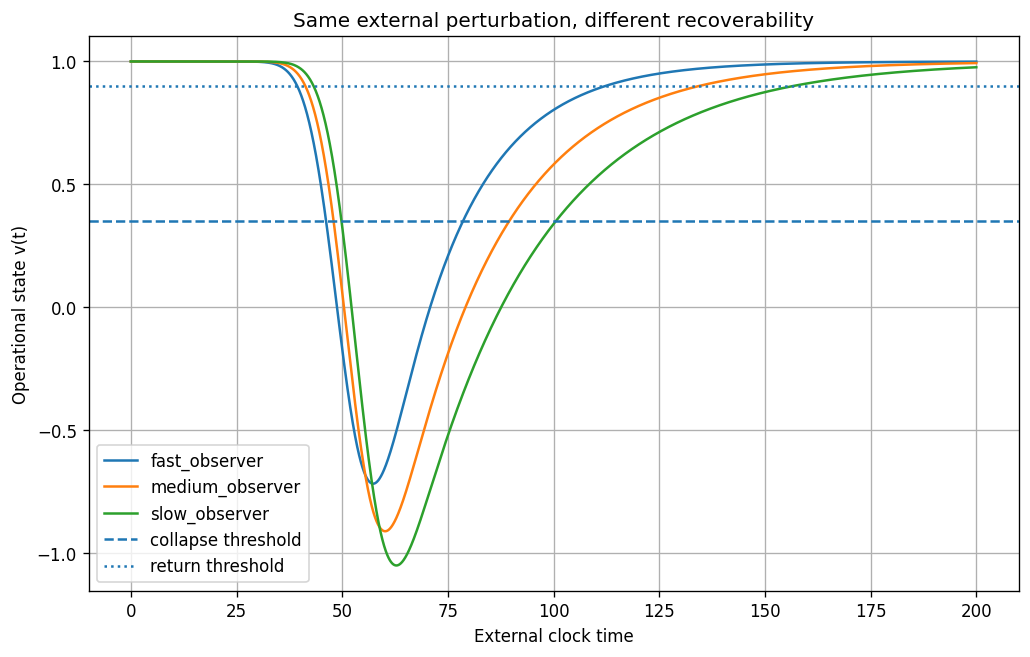

In [3]:
# ==========================================
# 2. SYSTEM CONFIGURATION
# ==========================================

observers = {
    "fast_observer": {"tau_r": 18.0, "delay": 0.0, "obs_window": 160.0},
    "medium_observer": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
    "slow_observer": {"tau_r": 30.0, "delay": 4.0, "obs_window": 160.0},
}

shared_input = {"auc": 3.0, "sigma": 6.0, "t0": 50.0, "T": 200.0, "dt": 0.05}

results = {}
summary = []

for name, params in observers.items():
    r = simulate_observer(**shared_input, **params)
    results[name] = r
    summary.append({
        "observer": name,
        "tau_r": params["tau_r"],
        "delay": params["delay"],
        "obs_window": params["obs_window"],
        "v_min": r["v_min"],
        "collapsed": r["collapsed"],
        "recovered": r["recovered"],
        "t_return": r["t_return"],
    })

summary_df = pd.DataFrame(summary)
save_table(summary_df, "observer_recoverability_single_pulse_summary.csv")
display(summary_df)

plt.figure(figsize=(10, 6))
for name, r in results.items():
    plt.plot(r["t"], r["v"], label=name)
plt.axhline(0.35, linestyle="--", label="collapse threshold")
plt.axhline(0.90, linestyle=":", label="return threshold")
plt.xlabel("External clock time")
plt.ylabel("Operational state v(t)")
plt.title("Same external perturbation, different recoverability")
plt.legend()
plt.grid(True)
save_current_fig("observer_dependent_recoverability_trajectories.png")
plt.show()

## 3. Recoverability maps and homogeneous control

We first map recoverability across perturbation load (`AUC`) and forcing duration (`sigma`). A homogeneous control checks whether differential accessibility disappears when internal recovery dynamics are identical.

,observer,recovered_fraction,collapsed_fraction,mean_v_min,median_t_return
0,fast_observer,1.000000,0.936111,-0.667603,112.775
1,medium_observer,1.000000,0.965833,-0.856382,134.800
2,slow_observer,0.579444,0.981389,-0.994297,157.000


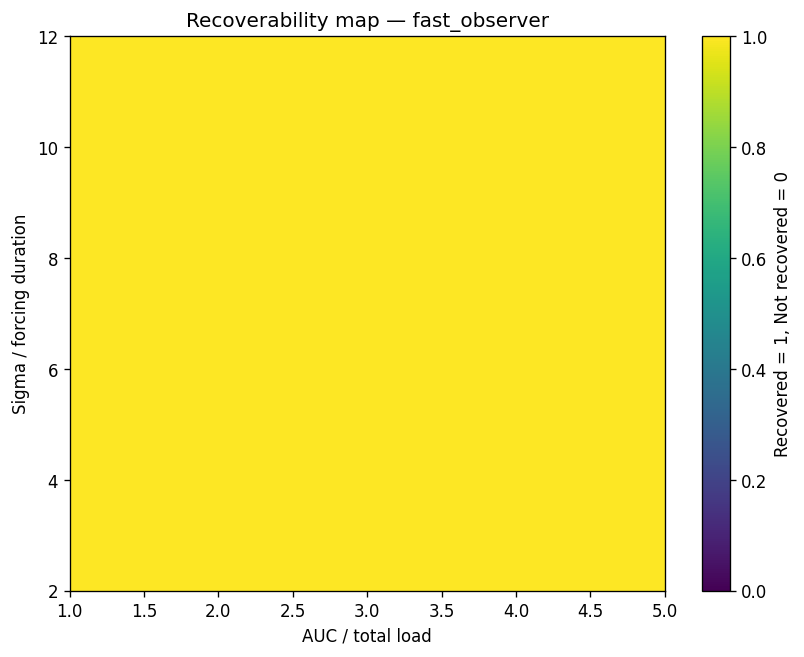

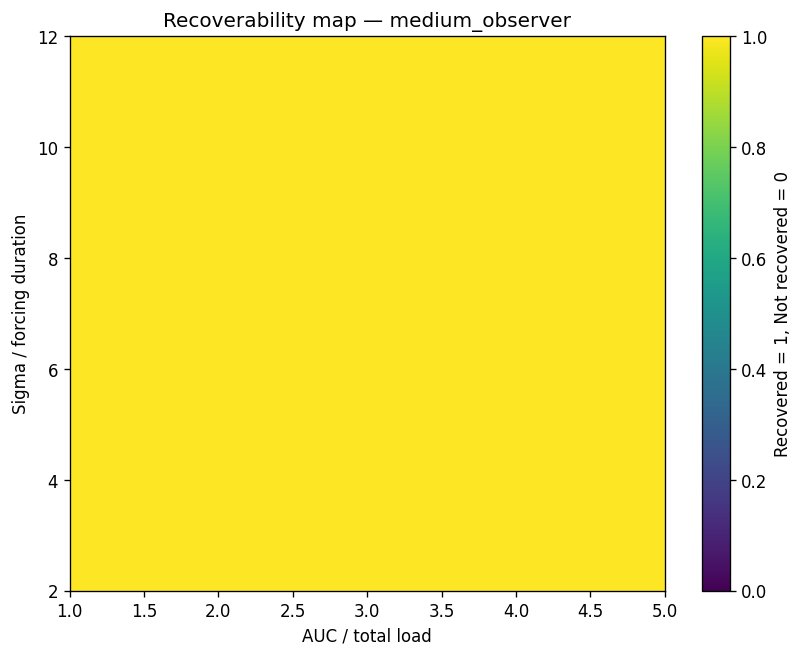

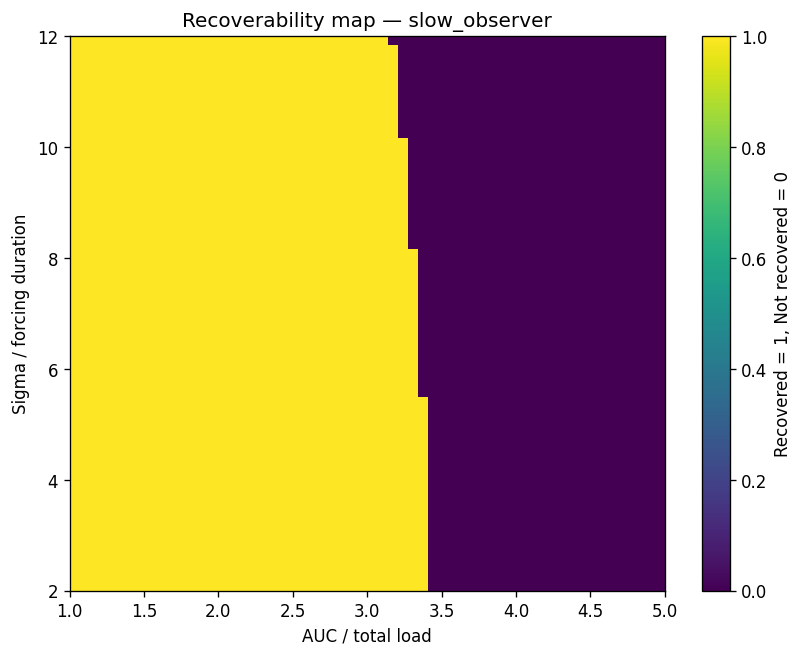

In [4]:
# ==========================================
# 3. PARAMETER SWEEP: AUC x SIGMA
# ==========================================

auc_values = np.linspace(1.0, 5.0, 60)
sigma_values = np.linspace(2.0, 12.0, 60)

sweep_rows = []
for observer_name, observer_params in observers.items():
    for auc in auc_values:
        for sigma in sigma_values:
            r = simulate_observer(
                auc=auc,
                sigma=sigma,
                t0=50.0,
                T=220.0,
                dt=0.05,
                **observer_params,
            )
            sweep_rows.append({
                "observer": observer_name,
                "auc": auc,
                "sigma": sigma,
                "tau_r": observer_params["tau_r"],
                "delay": observer_params["delay"],
                "obs_window": observer_params["obs_window"],
                "v_min": r["v_min"],
                "collapsed": r["collapsed"],
                "recovered": r["recovered"],
                "t_return": r["t_return"],
            })

sweep_df = pd.DataFrame(sweep_rows)
save_table(sweep_df, "observer_accessibility_sweep_auc_sigma_critical_regime.csv")

accessibility_summary = sweep_df.groupby("observer").agg(
    recovered_fraction=("recovered", "mean"),
    collapsed_fraction=("collapsed", "mean"),
    mean_v_min=("v_min", "mean"),
    median_t_return=("t_return", "median"),
).reset_index()
save_table(accessibility_summary, "observer_accessibility_summary_critical_regime.csv")
display(accessibility_summary)

for observer_name in observers.keys():
    sub = sweep_df[sweep_df["observer"] == observer_name]
    heatmap_data = sub.pivot(index="sigma", columns="auc", values="recovered").astype(float)
    plt.figure(figsize=(8, 6))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[auc_values.min(), auc_values.max(), sigma_values.min(), sigma_values.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Recovered = 1, Not recovered = 0")
    plt.xlabel("AUC / total load")
    plt.ylabel("Sigma / forcing duration")
    plt.title(f"Recoverability map — {observer_name}")
    save_current_fig(f"recoverability_heatmap_critical_{observer_name}.png")
    plt.show()

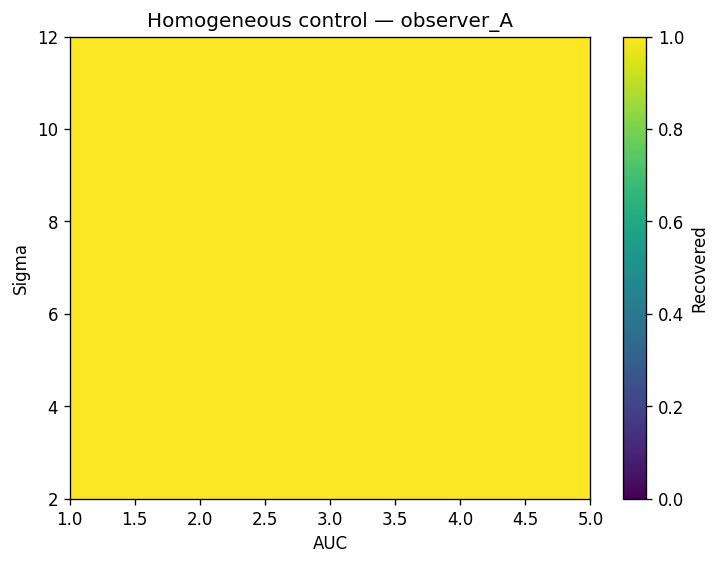

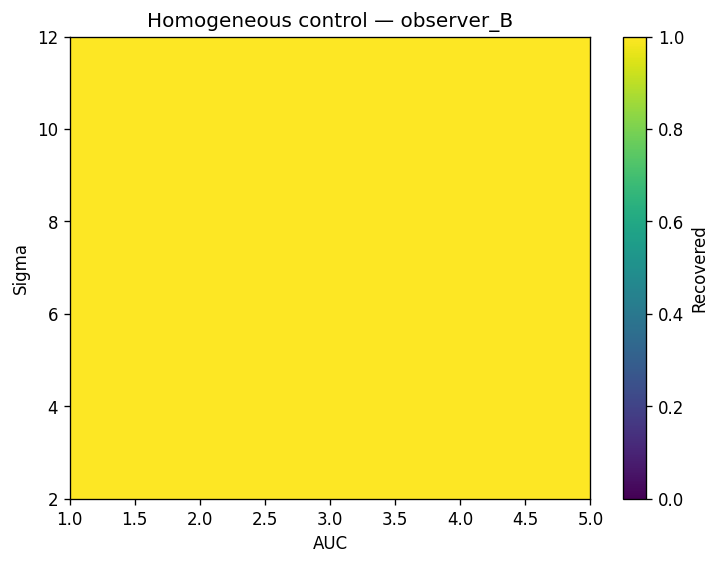

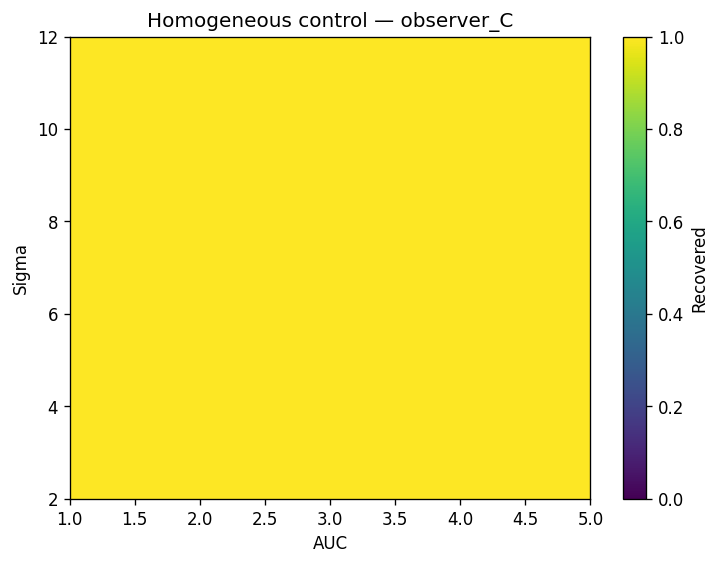

In [5]:
# ==========================================
# 3B. HOMOGENEOUS CONTROL MAPS
# ==========================================

homogeneous_observers = {
    "observer_A": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
    "observer_B": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
    "observer_C": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
}

homogeneous_rows = []
for observer_name, observer_params in homogeneous_observers.items():
    for auc in auc_values:
        for sigma in sigma_values:
            r = simulate_observer(auc=auc, sigma=sigma, t0=50.0, T=220.0, dt=0.05, **observer_params)
            homogeneous_rows.append({"observer": observer_name, "auc": auc, "sigma": sigma, "recovered": r["recovered"]})

homogeneous_df = pd.DataFrame(homogeneous_rows)
save_table(homogeneous_df, "homogeneous_control_recoverability_sweep.csv")

for observer_name in homogeneous_observers.keys():
    sub = homogeneous_df[homogeneous_df["observer"] == observer_name]
    heatmap_data = sub.pivot(index="sigma", columns="auc", values="recovered").astype(float)
    plt.figure(figsize=(7, 5))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[auc_values.min(), auc_values.max(), sigma_values.min(), sigma_values.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Recovered")
    plt.xlabel("AUC")
    plt.ylabel("Sigma")
    plt.title(f"Homogeneous control — {observer_name}")
    save_current_fig(f"homogeneous_control_{observer_name}.png")
    plt.show()

## 4. Temporal forcing sequence and future accessibility probes

We now apply repeated perturbations under a shared external time sequence. At successive times, we probe whether a standardized future perturbation remains recoverable.

,observer,tau_r,delay,v_min,collapsed,recovered_after_sequence,t_return_after_sequence
0,fast_observer,18.0,0.0,-1.177845,True,False,277.95
1,medium_observer,24.0,2.0,-1.622892,True,False,NaN
2,slow_observer,30.0,4.0,-2.052675,True,False,NaN


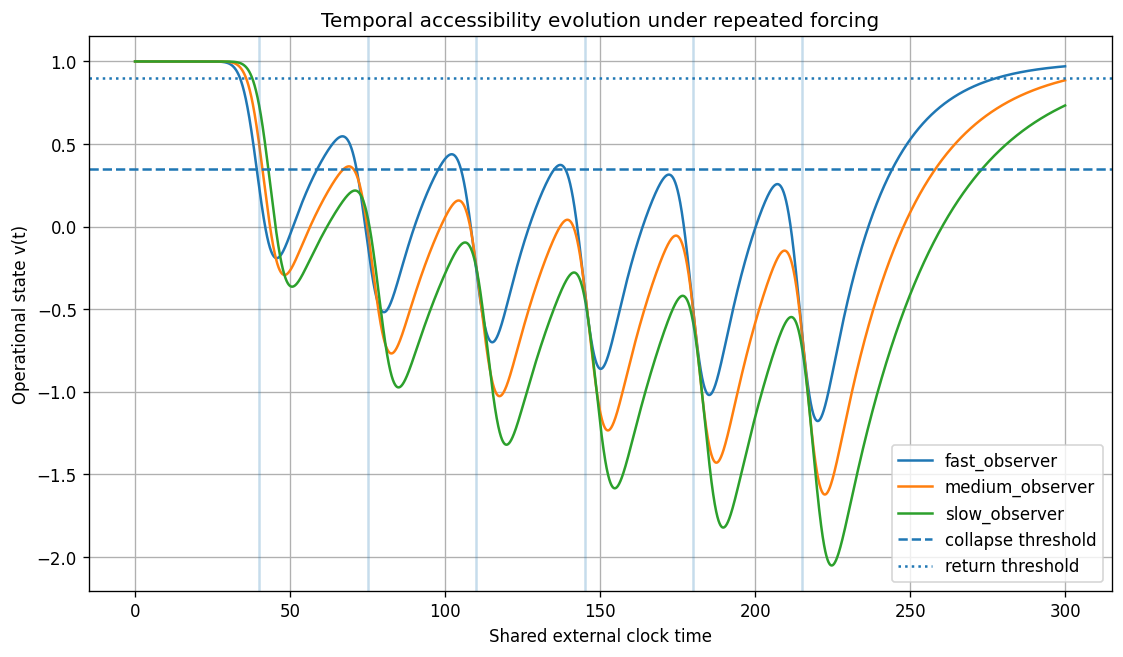

In [6]:
# ==========================================
# 4. TEMPORAL FORCING SEQUENCE
# ==========================================

pulses = [
    {"auc": 1.8, "sigma": 4.0, "t0": 40.0},
    {"auc": 2.0, "sigma": 4.0, "t0": 75.0},
    {"auc": 2.2, "sigma": 4.0, "t0": 110.0},
    {"auc": 2.4, "sigma": 4.0, "t0": 145.0},
    {"auc": 2.6, "sigma": 4.0, "t0": 180.0},
    {"auc": 2.8, "sigma": 4.0, "t0": 215.0},
]

temporal_results = {}
temporal_summary = []

for name, params in observers.items():
    r = simulate_observer_multi_pulse(pulses=pulses, tau_r=params["tau_r"], delay=params["delay"], obs_window=params["obs_window"], T=300.0, dt=0.05)
    temporal_results[name] = r
    temporal_summary.append({
        "observer": name,
        "tau_r": params["tau_r"],
        "delay": params["delay"],
        "v_min": r["v_min"],
        "collapsed": r["collapsed"],
        "recovered_after_sequence": r["recovered"],
        "t_return_after_sequence": r["t_return"],
    })

temporal_summary_df = pd.DataFrame(temporal_summary)
save_table(temporal_summary_df, "temporal_sequence_summary.csv")
display(temporal_summary_df)

plt.figure(figsize=(11, 6))
for name, r in temporal_results.items():
    plt.plot(r["t"], r["v"], label=name)
plt.axhline(0.35, linestyle="--", label="collapse threshold")
plt.axhline(0.90, linestyle=":", label="return threshold")
for p in pulses:
    plt.axvline(p["t0"], alpha=0.25)
plt.xlabel("Shared external clock time")
plt.ylabel("Operational state v(t)")
plt.title("Temporal accessibility evolution under repeated forcing")
plt.legend()
plt.grid(True)
save_current_fig("temporal_accessibility_evolution_repeated_forcing.png")
plt.show()

In [7]:
# ==========================================
# 4B. FUTURE ACCESSIBILITY PROBE FUNCTIONS
# ==========================================

def simulate_future_probe(
    v_start,
    auc=1.2,
    sigma=4.0,
    tau_r=24.0,
    delay=0.0,
    T_probe=120.0,
    dt=0.05,
    t0_probe=20.0,
    v_collapse=0.35,
    v_return=0.90,
):
    """Prospective future perturbation probe from an arbitrary state."""
    t = np.arange(0, T_probe + dt, dt)
    v = np.zeros_like(t)
    v[0] = v_start

    for k in range(1, len(t)):
        effective_t = t[k - 1] - delay
        E = gaussian_pulse(effective_t, auc=auc, sigma=sigma, t0=t0_probe)
        dv = ((1 - v[k - 1]) / tau_r) - E
        v[k] = v[k - 1] + dv * dt

    after_probe = t > (t0_probe + 2 * sigma + delay)
    returned_indices = np.where((after_probe) & (v >= v_return))[0]
    recovered = len(returned_indices) > 0
    t_return = float(t[returned_indices[0]]) if recovered else np.nan
    v_min = float(np.min(v))
    collapsed = bool(v_min < v_collapse)
    return {"recovered": recovered, "t_return": t_return, "v_min": v_min, "collapsed": collapsed}


def simulate_future_probe_noisy(
    v_start,
    auc=1.2,
    sigma=4.0,
    tau_r=24.0,
    delay=0.0,
    T_probe=120.0,
    dt=0.05,
    t0_probe=20.0,
    v_collapse=0.35,
    v_return=0.90,
    noise_strength=0.01,
    seed=None,
):
    """Noisy prospective future perturbation probe."""
    rng = np.random.default_rng(seed)
    t = np.arange(0, T_probe + dt, dt)
    v = np.zeros_like(t)
    v[0] = v_start

    for k in range(1, len(t)):
        effective_t = t[k - 1] - delay
        E = gaussian_pulse(effective_t, auc=auc, sigma=sigma, t0=t0_probe)
        noise = noise_strength * rng.normal()
        dv = ((1 - v[k - 1]) / tau_r) - E + noise
        v[k] = v[k - 1] + dv * dt

    after_probe = t > (t0_probe + 2 * sigma + delay)
    returned_indices = np.where((after_probe) & (v >= v_return))[0]
    recovered = len(returned_indices) > 0
    t_return = float(t[returned_indices[0]]) if recovered else np.nan
    v_min = float(np.min(v))
    collapsed = bool(v_min < v_collapse)
    return {"recovered": recovered, "t_return": t_return, "v_min": v_min, "collapsed": collapsed}

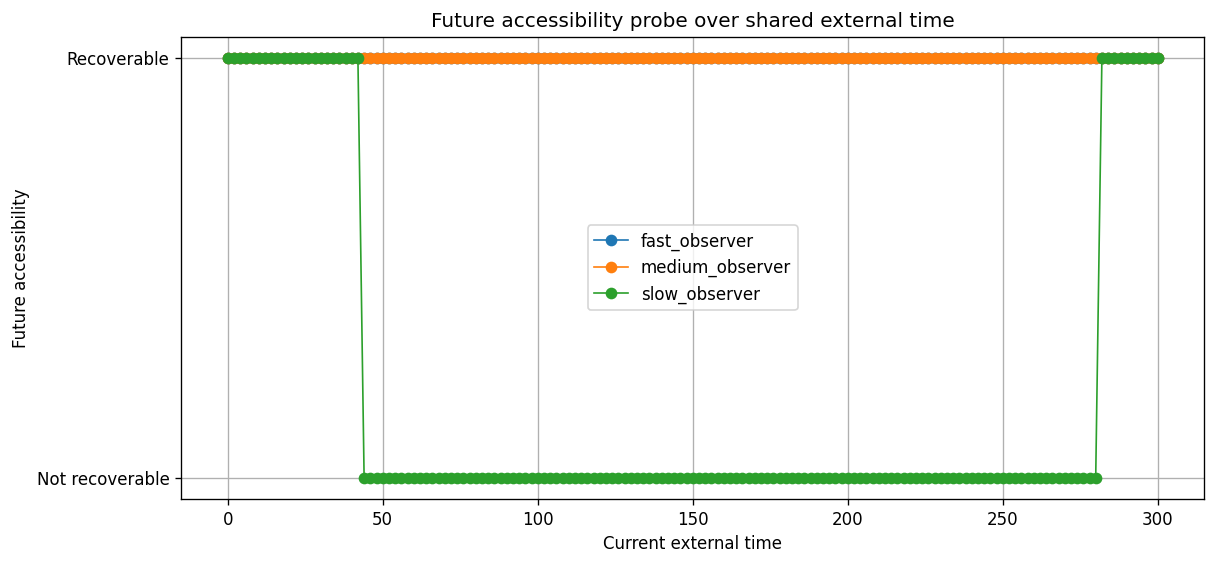

In [8]:
# ==========================================
# 4C. FUTURE ACCESSIBILITY OVER TIME
# ==========================================

probe_auc = 2.2
probe_sigma = 4.5
future_access_rows = []

for observer_name, r in temporal_results.items():
    params = observers[observer_name]
    sample_step = 40
    for idx in range(0, len(r["t"]), sample_step):
        current_time = float(r["t"][idx])
        current_v = float(r["v"][idx])
        probe = simulate_future_probe(v_start=current_v, auc=probe_auc, sigma=probe_sigma, tau_r=params["tau_r"], delay=params["delay"], T_probe=120.0, dt=0.05, t0_probe=20.0)
        future_access_rows.append({
            "observer": observer_name,
            "current_time": current_time,
            "current_v": current_v,
            "future_probe_auc": probe_auc,
            "future_probe_sigma": probe_sigma,
            "future_recoverable": probe["recovered"],
            "future_t_return": probe["t_return"],
            "future_v_min": probe["v_min"],
            "future_collapsed": probe["collapsed"],
        })

future_access_df = pd.DataFrame(future_access_rows)
save_table(future_access_df, "future_accessibility_probe_over_time_strong_probe.csv")

plt.figure(figsize=(11, 5))
for observer_name in observers.keys():
    sub = future_access_df[future_access_df["observer"] == observer_name]
    plt.plot(sub["current_time"], sub["future_recoverable"].astype(int), marker="o", linewidth=1, label=observer_name)
plt.yticks([0, 1], ["Not recoverable", "Recoverable"])
plt.xlabel("Current external time")
plt.ylabel("Future accessibility")
plt.title("Future accessibility probe over shared external time")
plt.legend()
plt.grid(True)
save_current_fig("future_accessibility_probe_over_time.png")
plt.show()

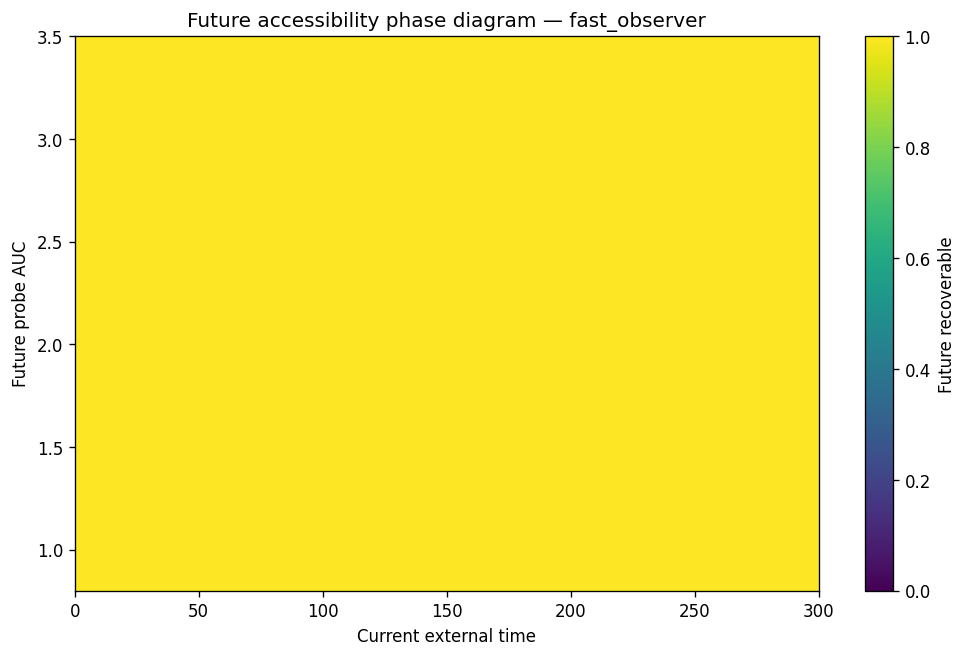

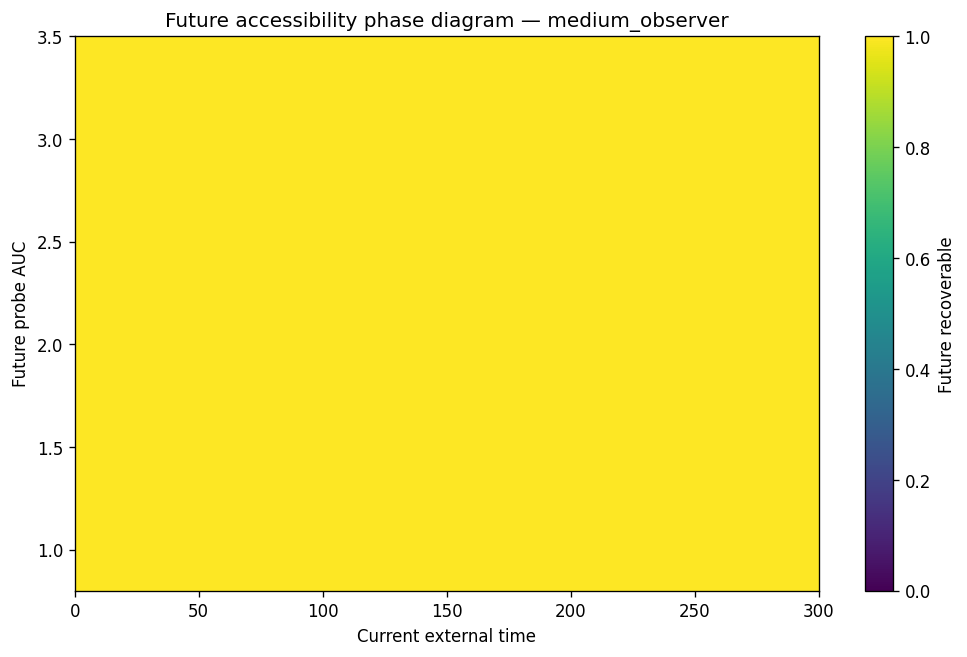

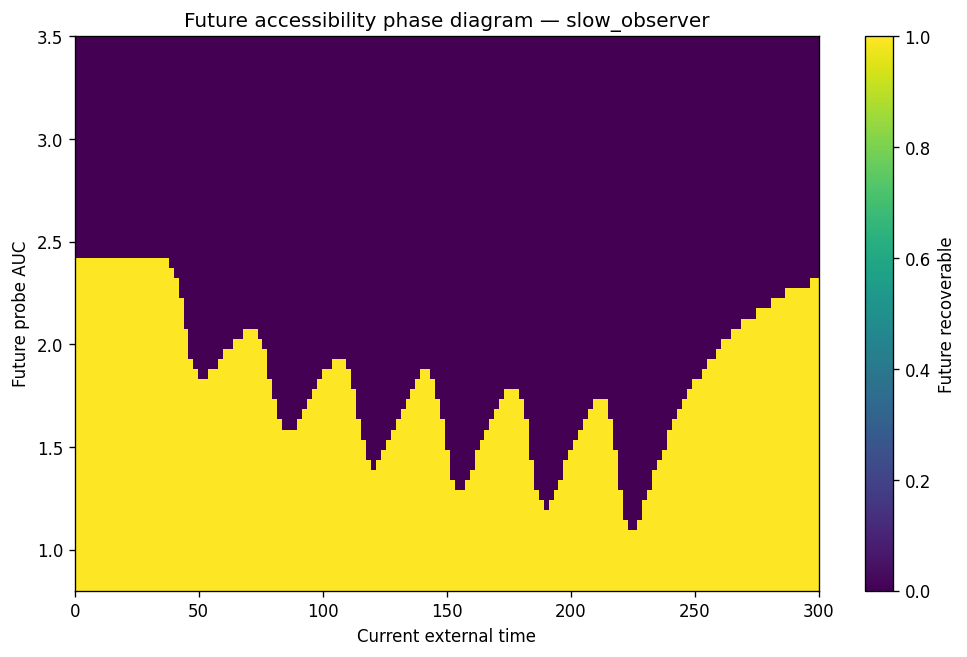

In [9]:
# ==========================================
# 4D. FUTURE ACCESSIBILITY PHASE DIAGRAMS
# ==========================================

probe_auc_values = np.linspace(0.8, 3.5, 55)
phase_rows = []

for observer_name, r in temporal_results.items():
    params = observers[observer_name]
    sample_step = 40
    for idx in range(0, len(r["t"]), sample_step):
        current_time = float(r["t"][idx])
        current_v = float(r["v"][idx])
        for probe_auc in probe_auc_values:
            probe = simulate_future_probe(v_start=current_v, auc=probe_auc, sigma=4.5, tau_r=params["tau_r"], delay=params["delay"], T_probe=120.0, dt=0.05, t0_probe=20.0)
            phase_rows.append({
                "observer": observer_name,
                "current_time": current_time,
                "current_v": current_v,
                "probe_auc": probe_auc,
                "future_recoverable": probe["recovered"],
                "future_v_min": probe["v_min"],
                "future_collapsed": probe["collapsed"],
            })

phase_df = pd.DataFrame(phase_rows)
save_table(phase_df, "future_accessibility_phase_diagram.csv")

for observer_name in observers.keys():
    sub = phase_df[phase_df["observer"] == observer_name]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="future_recoverable").astype(float)
    plt.figure(figsize=(10, 6))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[sub["current_time"].min(), sub["current_time"].max(), probe_auc_values.min(), probe_auc_values.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Future recoverable")
    plt.xlabel("Current external time")
    plt.ylabel("Future probe AUC")
    plt.title(f"Future accessibility phase diagram — {observer_name}")
    save_current_fig(f"future_accessibility_phase_diagram_{observer_name}.png")
    plt.show()

## 5. Robustness checks

We test whether the main slow-system future-accessibility geometry persists across timestep (`dt`) and probe-width (`probe_sigma`) changes.

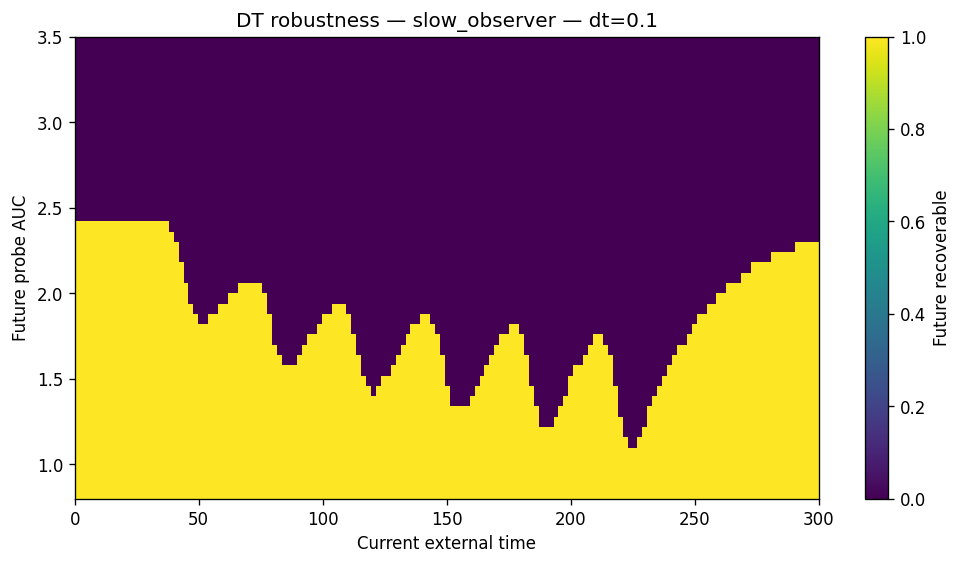

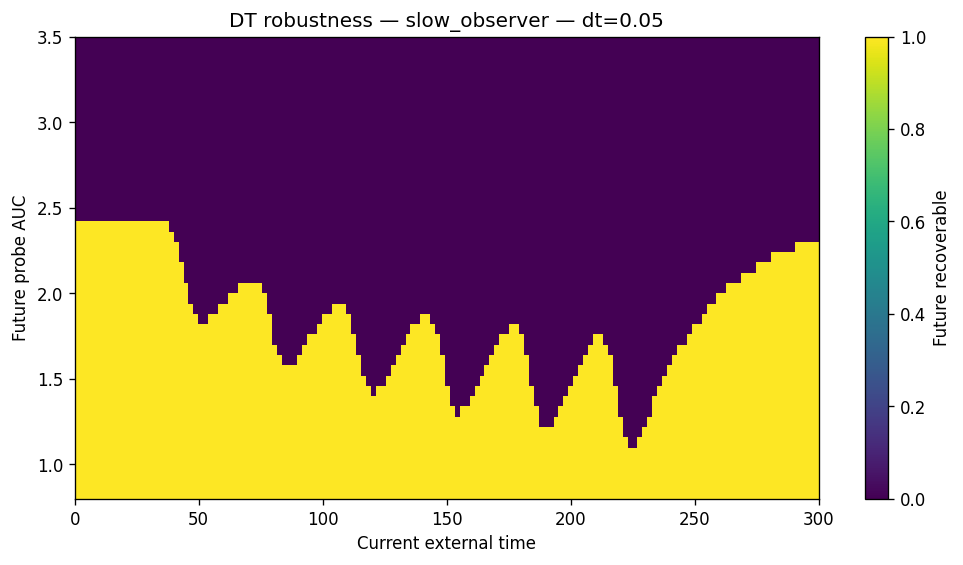

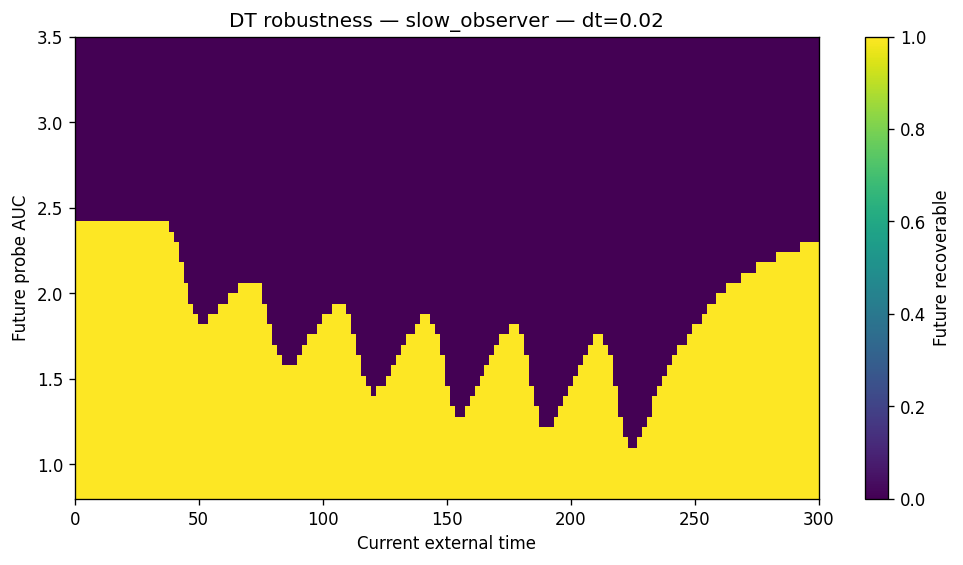

In [10]:
# ==========================================
# 5A. DT ROBUSTNESS
# ==========================================

dt_values = [0.10, 0.05, 0.02]
probe_auc_values_robust = np.linspace(0.8, 3.5, 45)
dt_robust_rows = []
target_observer = "slow_observer"
params = observers[target_observer]

for dt_test in dt_values:
    r = simulate_observer_multi_pulse(pulses=pulses, tau_r=params["tau_r"], delay=params["delay"], obs_window=params["obs_window"], T=300.0, dt=dt_test)
    sample_step = max(1, int(2.0 / dt_test))
    for idx in range(0, len(r["t"]), sample_step):
        current_time = float(r["t"][idx])
        current_v = float(r["v"][idx])
        for probe_auc in probe_auc_values_robust:
            probe = simulate_future_probe(v_start=current_v, auc=probe_auc, sigma=4.5, tau_r=params["tau_r"], delay=params["delay"], T_probe=120.0, dt=dt_test, t0_probe=20.0)
            dt_robust_rows.append({
                "dt": dt_test,
                "observer": target_observer,
                "current_time": current_time,
                "current_v": current_v,
                "probe_auc": probe_auc,
                "future_recoverable": probe["recovered"],
                "future_v_min": probe["v_min"],
                "future_collapsed": probe["collapsed"],
            })

dt_robust_df = pd.DataFrame(dt_robust_rows)
save_table(dt_robust_df, "robustness_dt_sensitivity_slow_observer.csv")

for dt_test in dt_values:
    sub = dt_robust_df[dt_robust_df["dt"] == dt_test]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="future_recoverable").astype(float)
    plt.figure(figsize=(10, 5))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[sub["current_time"].min(), sub["current_time"].max(), probe_auc_values_robust.min(), probe_auc_values_robust.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Future recoverable")
    plt.xlabel("Current external time")
    plt.ylabel("Future probe AUC")
    plt.title(f"DT robustness — slow_observer — dt={dt_test}")
    save_current_fig(f"dt_robustness_slow_observer_dt_{dt_test}.png")
    plt.show()

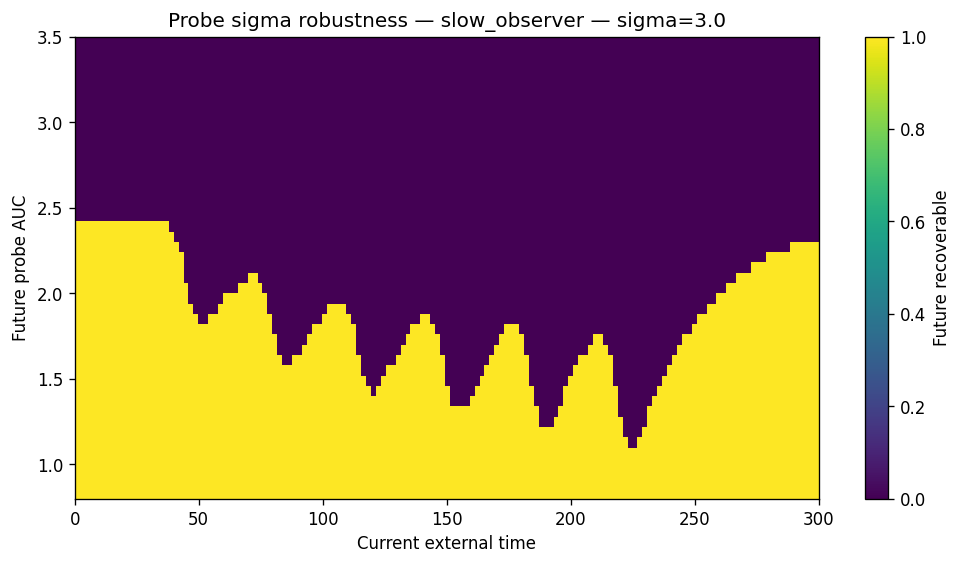

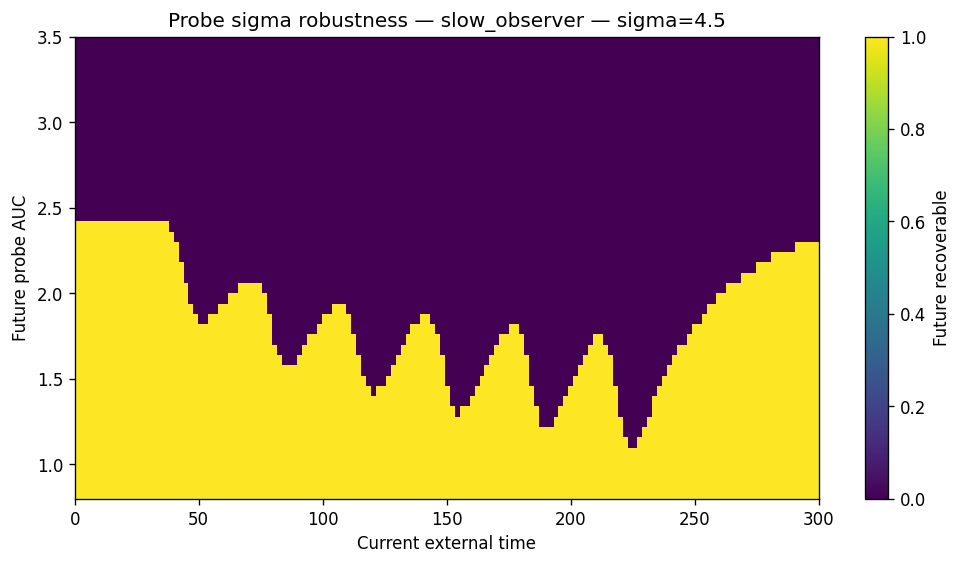

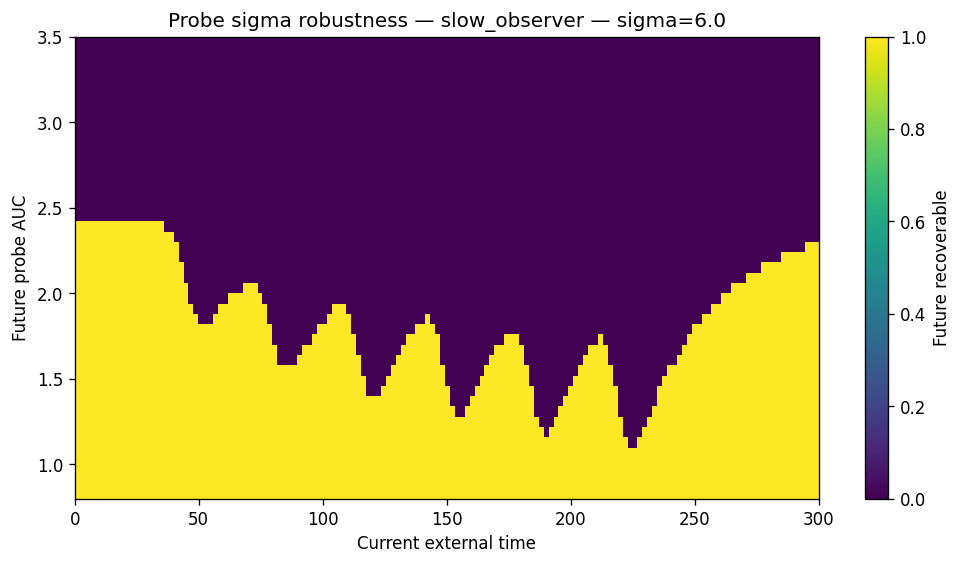

In [11]:
# ==========================================
# 5B. PROBE SIGMA ROBUSTNESS
# ==========================================

probe_sigma_values = [3.0, 4.5, 6.0]
probe_auc_values_sigma = np.linspace(0.8, 3.5, 45)
sigma_robust_rows = []
dt_test = 0.05
r = simulate_observer_multi_pulse(pulses=pulses, tau_r=params["tau_r"], delay=params["delay"], obs_window=params["obs_window"], T=300.0, dt=dt_test)
sample_step = max(1, int(2.0 / dt_test))

for probe_sigma_test in probe_sigma_values:
    for idx in range(0, len(r["t"]), sample_step):
        current_time = float(r["t"][idx])
        current_v = float(r["v"][idx])
        for probe_auc in probe_auc_values_sigma:
            probe = simulate_future_probe(v_start=current_v, auc=probe_auc, sigma=probe_sigma_test, tau_r=params["tau_r"], delay=params["delay"], T_probe=120.0, dt=dt_test, t0_probe=20.0)
            sigma_robust_rows.append({
                "probe_sigma": probe_sigma_test,
                "observer": target_observer,
                "current_time": current_time,
                "current_v": current_v,
                "probe_auc": probe_auc,
                "future_recoverable": probe["recovered"],
                "future_v_min": probe["v_min"],
                "future_collapsed": probe["collapsed"],
            })

sigma_robust_df = pd.DataFrame(sigma_robust_rows)
save_table(sigma_robust_df, "robustness_probe_sigma_slow_observer.csv")

for probe_sigma_test in probe_sigma_values:
    sub = sigma_robust_df[sigma_robust_df["probe_sigma"] == probe_sigma_test]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="future_recoverable").astype(float)
    plt.figure(figsize=(10, 5))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[sub["current_time"].min(), sub["current_time"].max(), probe_auc_values_sigma.min(), probe_auc_values_sigma.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Future recoverable")
    plt.xlabel("Current external time")
    plt.ylabel("Future probe AUC")
    plt.title(f"Probe sigma robustness — slow_observer — sigma={probe_sigma_test}")
    save_current_fig(f"probe_sigma_robustness_slow_observer_sigma_{probe_sigma_test}.png")
    plt.show()

## 6. Stochastic accessibility, fragmentation, and percolation

Stochastic future probes convert deterministic boundaries into probabilistic accessibility landscapes. We then quantify fragmentation and percolation-like degradation of global accessibility coherence.

Running noise: 0.0
Running noise: 0.01
Running noise: 0.02
Running noise: 0.05


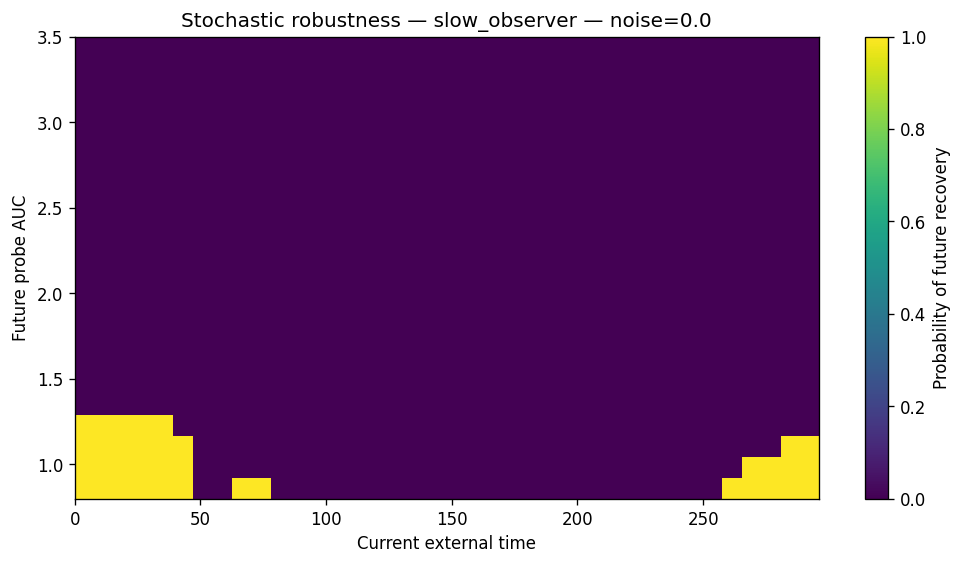

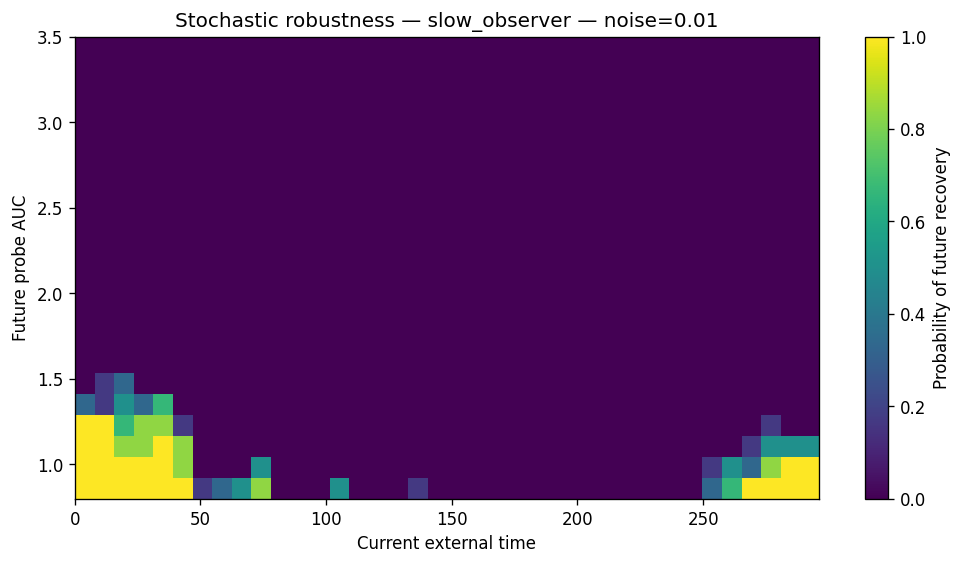

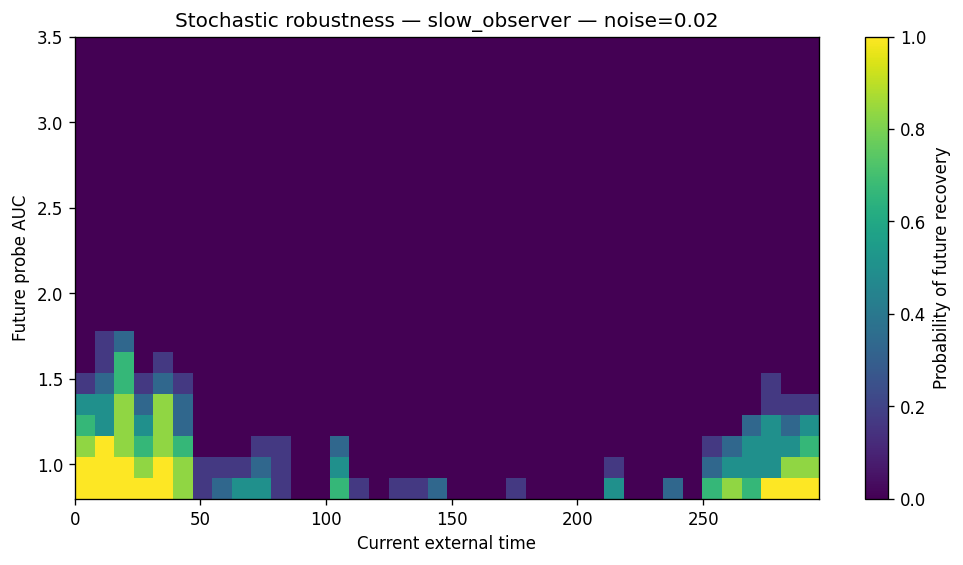

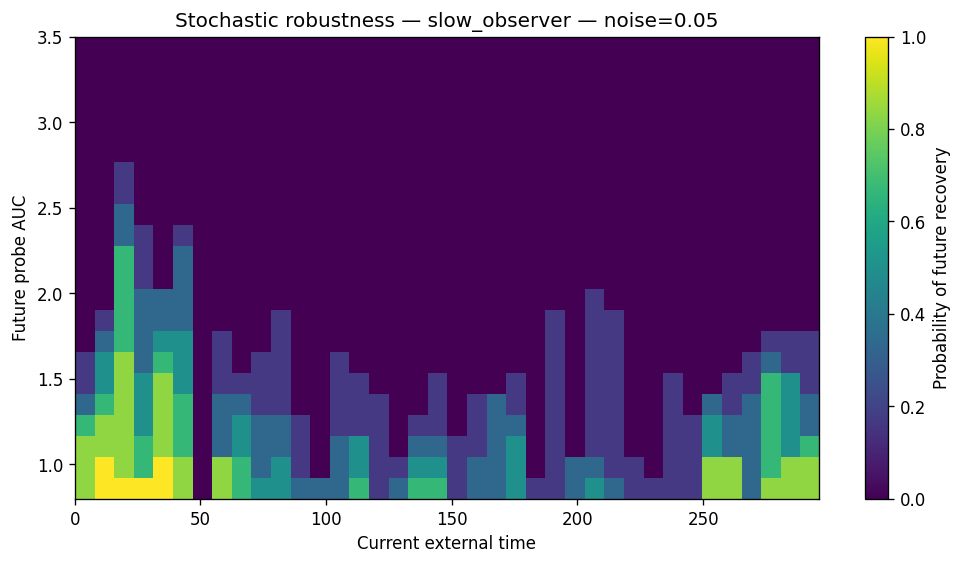

In [12]:
# ==========================================
# 6A. STOCHASTIC ROBUSTNESS — FAST VERSION
# ==========================================

noise_values = [0.00, 0.01, 0.02, 0.05]
n_replicates = 6
probe_auc_values_noise = np.linspace(0.8, 3.5, 22)
target_observer = "slow_observer"
params = observers[target_observer]
dt_test = 0.05
r = simulate_observer_multi_pulse(pulses=pulses, tau_r=params["tau_r"], delay=params["delay"], obs_window=params["obs_window"], T=300.0, dt=dt_test)
sample_step = max(1, int(8.0 / dt_test))
noise_rows = []

for noise_strength in noise_values:
    print("Running noise:", noise_strength)
    for idx in range(0, len(r["t"]), sample_step):
        current_time = float(r["t"][idx])
        current_v = float(r["v"][idx])
        for probe_auc in probe_auc_values_noise:
            recovered_list = []
            vmin_list = []
            for rep in range(n_replicates):
                seed = int(100000 * noise_strength + 1000 * rep + idx)
                probe = simulate_future_probe_noisy(v_start=current_v, auc=probe_auc, sigma=4.5, tau_r=params["tau_r"], delay=params["delay"], T_probe=100.0, dt=dt_test, t0_probe=20.0, noise_strength=noise_strength, seed=seed)
                recovered_list.append(probe["recovered"])
                vmin_list.append(probe["v_min"])
            noise_rows.append({
                "noise_strength": noise_strength,
                "observer": target_observer,
                "current_time": current_time,
                "current_v": current_v,
                "probe_auc": probe_auc,
                "recovery_probability": float(np.mean(recovered_list)),
                "mean_future_v_min": float(np.mean(vmin_list)),
                "std_future_v_min": float(np.std(vmin_list)),
            })

noise_robust_df = pd.DataFrame(noise_rows)
save_table(noise_robust_df, "stochastic_robustness_slow_observer_FAST.csv")

for noise_strength in noise_values:
    sub = noise_robust_df[noise_robust_df["noise_strength"] == noise_strength]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="recovery_probability").astype(float)
    plt.figure(figsize=(10, 5))
    plt.imshow(
        heatmap_data,
        origin="lower",
        aspect="auto",
        extent=[sub["current_time"].min(), sub["current_time"].max(), probe_auc_values_noise.min(), probe_auc_values_noise.max()],
        vmin=0,
        vmax=1,
    )
    plt.colorbar(label="Probability of future recovery")
    plt.xlabel("Current external time")
    plt.ylabel("Future probe AUC")
    plt.title(f"Stochastic robustness — slow_observer — noise={noise_strength}")
    save_current_fig(f"stochastic_robustness_slow_observer_noise_{noise_strength}.png")
    plt.show()

,noise_strength,n_accessible_components,total_accessible_cells,largest_component_cells,fragmentation_index
0,0.00,3,36,23,0.361111
1,0.01,4,41,25,0.390244
2,0.02,5,51,29,0.431373
3,0.05,8,86,45,0.476744


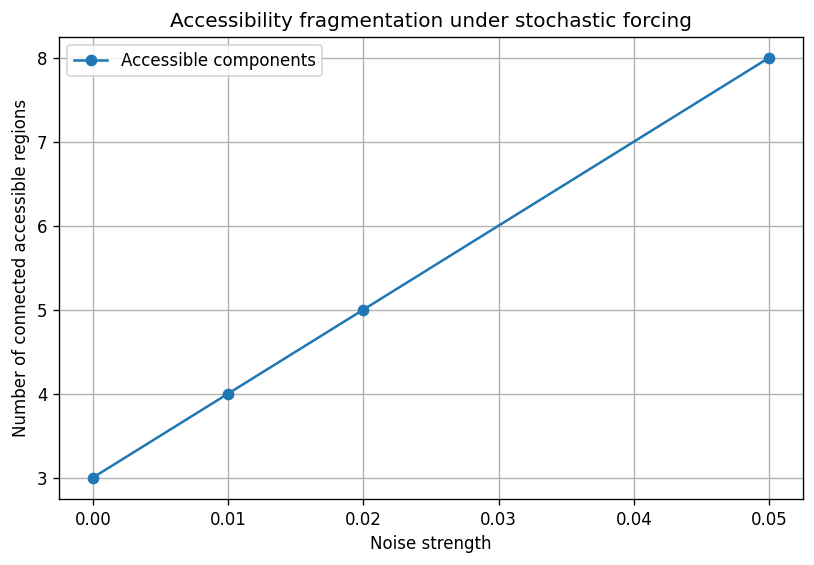

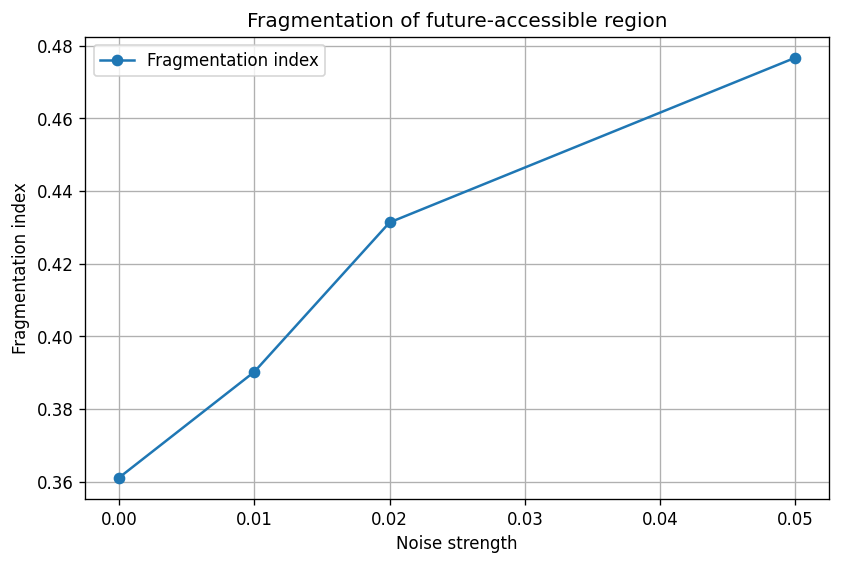

In [13]:
# ==========================================
# 6B. FRAGMENTATION METRICS
# ==========================================

fragmentation_rows = []
prob_threshold = 0.5

for noise_strength in noise_values:
    sub = noise_robust_df[noise_robust_df["noise_strength"] == noise_strength]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="recovery_probability").astype(float)
    accessible_binary = heatmap_data.values >= prob_threshold
    labeled_array, n_components = ndimage.label(accessible_binary)
    component_sizes = [np.sum(labeled_array == cid) for cid in range(1, n_components + 1)]
    largest_component = max(component_sizes) if component_sizes else 0
    total_accessible = int(np.sum(accessible_binary))
    fragmentation_rows.append({
        "noise_strength": noise_strength,
        "n_accessible_components": int(n_components),
        "total_accessible_cells": total_accessible,
        "largest_component_cells": int(largest_component),
        "fragmentation_index": 1 - largest_component / total_accessible if total_accessible > 0 else np.nan,
    })

fragmentation_df = pd.DataFrame(fragmentation_rows)
save_table(fragmentation_df, "accessibility_fragmentation_metrics.csv")
display(fragmentation_df)

plt.figure(figsize=(8, 5))
plt.plot(fragmentation_df["noise_strength"], fragmentation_df["n_accessible_components"], marker="o", label="Accessible components")
plt.xlabel("Noise strength")
plt.ylabel("Number of connected accessible regions")
plt.title("Accessibility fragmentation under stochastic forcing")
plt.grid(True)
plt.legend()
save_current_fig("accessibility_fragmentation_components_vs_noise.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(fragmentation_df["noise_strength"], fragmentation_df["fragmentation_index"], marker="o", label="Fragmentation index")
plt.xlabel("Noise strength")
plt.ylabel("Fragmentation index")
plt.title("Fragmentation of future-accessible region")
plt.grid(True)
plt.legend()
save_current_fig("accessibility_fragmentation_index_vs_noise.png")
plt.show()

,noise_strength,nodes_accessible,edges_accessible,n_components,largest_component_size,avg_degree,network_density
0,0.00,36,51,3,23,2.833333,0.080952
1,0.01,41,55,4,25,2.682927,0.067073
2,0.02,51,69,5,29,2.705882,0.054118
3,0.05,86,114,8,45,2.651163,0.031190


,noise_strength,total_accessible,largest_component,largest_component_fraction,n_components
0,0.00,36,23,0.638889,3
1,0.01,41,25,0.609756,4
2,0.02,51,29,0.568627,5
3,0.05,86,45,0.523256,8


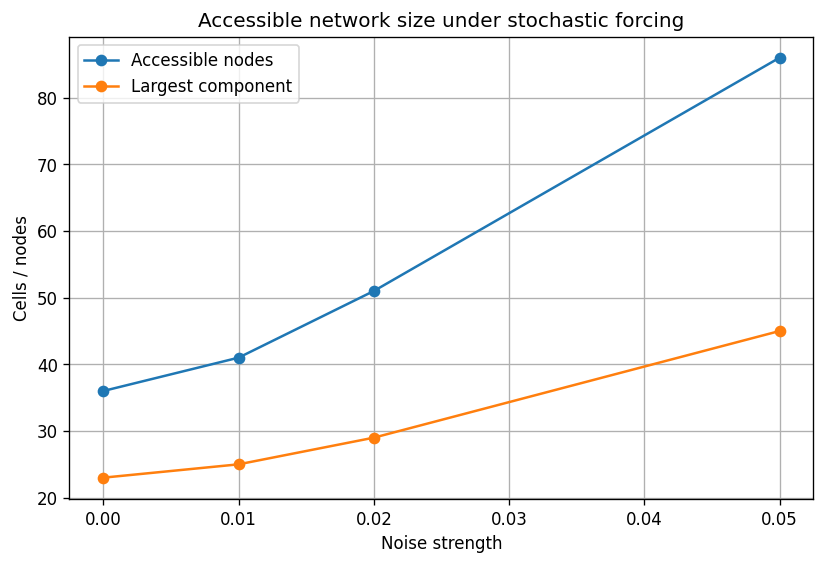

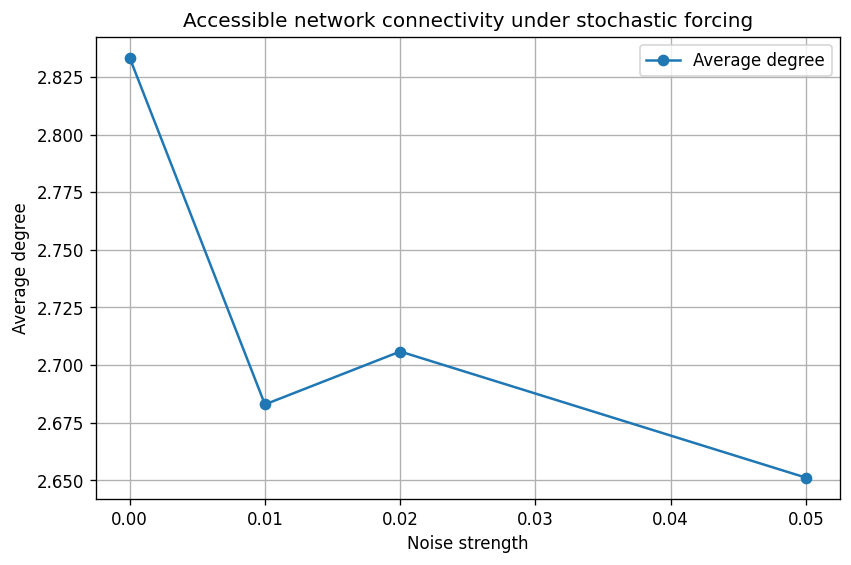

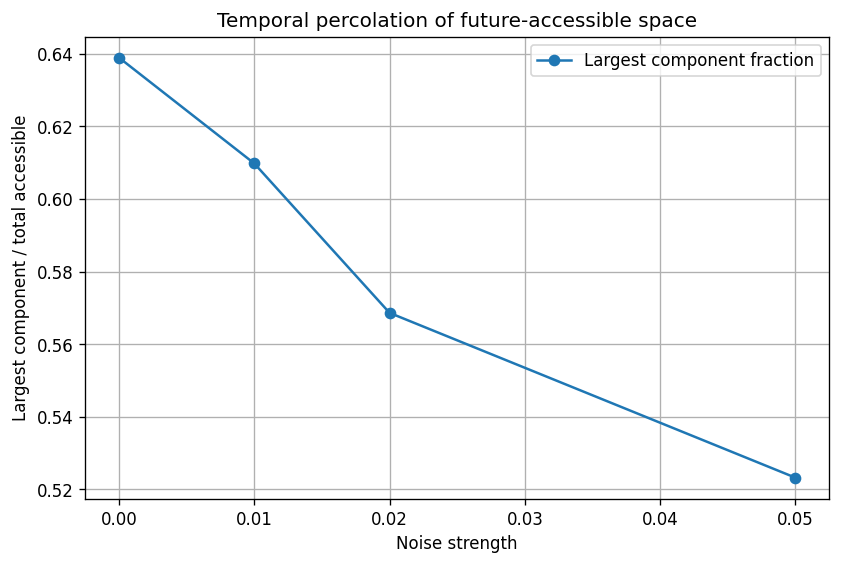

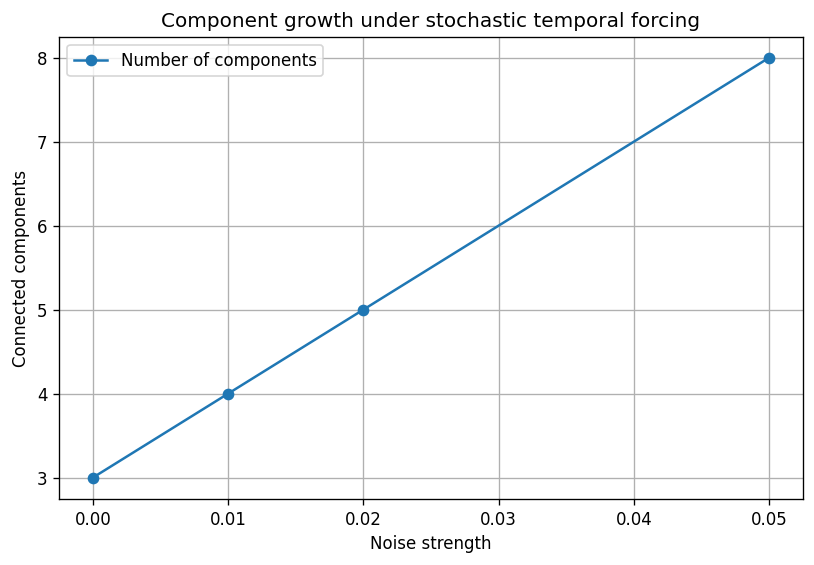

In [14]:
# ==========================================
# 6C. NETWORK GEOMETRY AND PERCOLATION METRICS
# ==========================================

network_rows = []
percolation_rows = []
prob_threshold = 0.5

for noise_strength in noise_values:
    sub = noise_robust_df[noise_robust_df["noise_strength"] == noise_strength]
    heatmap_data = sub.pivot(index="probe_auc", columns="current_time", values="recovery_probability").astype(float)
    accessible = heatmap_data.values >= prob_threshold

    # Graph connectivity on grid
    G = nx.Graph()
    n_rows, n_cols = accessible.shape
    for i in range(n_rows):
        for j in range(n_cols):
            if accessible[i, j]:
                G.add_node((i, j))
                if j > 0 and accessible[i, j - 1]:
                    G.add_edge((i, j), (i, j - 1))
                if i > 0 and accessible[i - 1, j]:
                    G.add_edge((i, j), (i - 1, j))

    if G.number_of_nodes() > 0:
        components = list(nx.connected_components(G))
        largest_component_size = max(len(c) for c in components)
        n_components = len(components)
        avg_degree = float(np.mean([deg for _, deg in G.degree()]))
        density = nx.density(G) if G.number_of_nodes() > 1 else 0.0
    else:
        largest_component_size = 0
        n_components = 0
        avg_degree = 0.0
        density = 0.0

    network_rows.append({
        "noise_strength": noise_strength,
        "nodes_accessible": G.number_of_nodes(),
        "edges_accessible": G.number_of_edges(),
        "n_components": n_components,
        "largest_component_size": largest_component_size,
        "avg_degree": avg_degree,
        "network_density": density,
    })

    total_accessible = int(np.sum(accessible))
    percolation_rows.append({
        "noise_strength": noise_strength,
        "total_accessible": total_accessible,
        "largest_component": largest_component_size,
        "largest_component_fraction": largest_component_size / total_accessible if total_accessible > 0 else np.nan,
        "n_components": n_components,
    })

network_df = pd.DataFrame(network_rows)
percolation_df = pd.DataFrame(percolation_rows)
save_table(network_df, "trajectory_network_geometry_metrics.csv")
save_table(percolation_df, "temporal_percolation_metrics.csv")

display(network_df)
display(percolation_df)

plt.figure(figsize=(8, 5))
plt.plot(network_df["noise_strength"], network_df["nodes_accessible"], marker="o", label="Accessible nodes")
plt.plot(network_df["noise_strength"], network_df["largest_component_size"], marker="o", label="Largest component")
plt.xlabel("Noise strength")
plt.ylabel("Cells / nodes")
plt.title("Accessible network size under stochastic forcing")
plt.grid(True)
plt.legend()
save_current_fig("trajectory_network_size_vs_noise.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(network_df["noise_strength"], network_df["avg_degree"], marker="o", label="Average degree")
plt.xlabel("Noise strength")
plt.ylabel("Average degree")
plt.title("Accessible network connectivity under stochastic forcing")
plt.grid(True)
plt.legend()
save_current_fig("trajectory_network_connectivity_vs_noise.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(percolation_df["noise_strength"], percolation_df["largest_component_fraction"], marker="o", label="Largest component fraction")
plt.xlabel("Noise strength")
plt.ylabel("Largest component / total accessible")
plt.title("Temporal percolation of future-accessible space")
plt.grid(True)
plt.legend()
save_current_fig("temporal_percolation_largest_component_fraction.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(percolation_df["noise_strength"], percolation_df["n_components"], marker="o", label="Number of components")
plt.xlabel("Noise strength")
plt.ylabel("Connected components")
plt.title("Component growth under stochastic temporal forcing")
plt.grid(True)
plt.legend()
save_current_fig("temporal_percolation_components.png")
plt.show()

## 7. Homogeneous vs heterogeneous control

This control tests whether fragmentation depends on heterogeneous internal recoverability structure rather than stochastic forcing alone.

,set_type,observer,tau_r,delay,total_accessible,largest_component,largest_component_fraction,n_components,fragmentation_index
0,heterogeneous,fast,18.0,0.0,836,836,1.000000,1,0.000000
1,heterogeneous,medium,24.0,2.0,441,441,1.000000,1,0.000000
2,heterogeneous,slow,30.0,4.0,46,27,0.586957,4,0.413043
3,homogeneous,A,24.0,2.0,426,426,1.000000,1,0.000000
4,homogeneous,B,24.0,2.0,447,447,1.000000,1,0.000000
5,homogeneous,C,24.0,2.0,449,449,1.000000,1,0.000000


,set_type,mean_components,mean_fragmentation,mean_largest_fraction,mean_accessible
0,heterogeneous,2.0,0.137681,0.862319,441.000000
1,homogeneous,1.0,0.000000,1.000000,440.666667


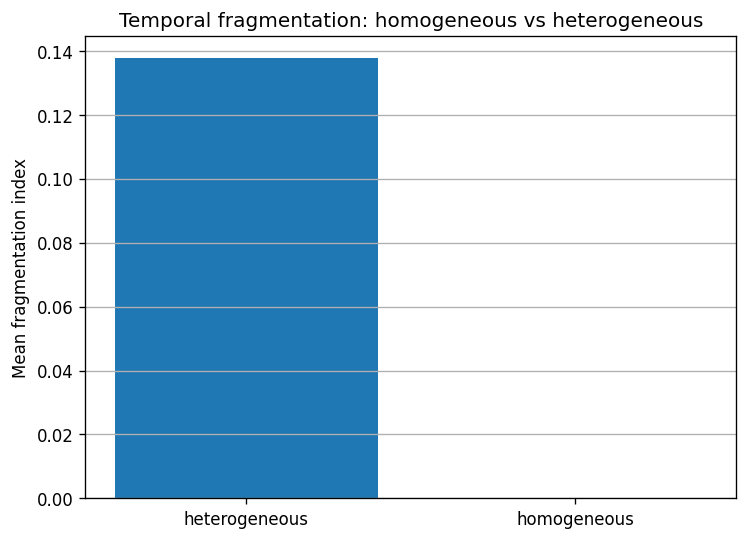

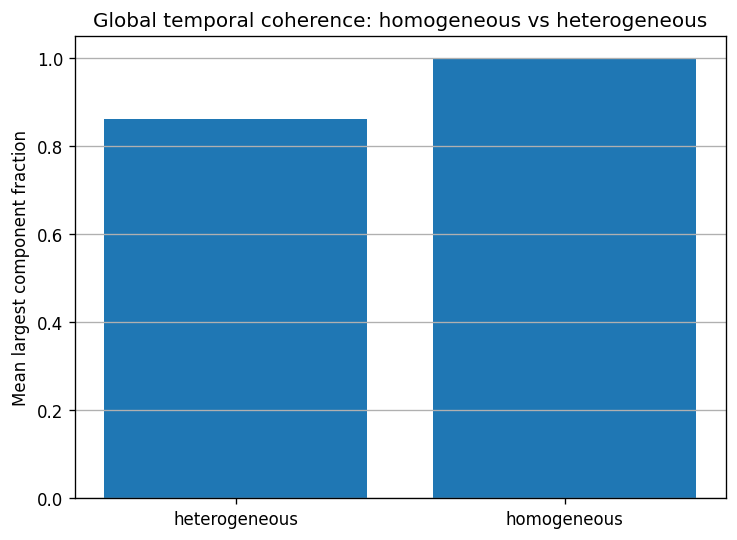

In [15]:
# ==========================================
# 7. HOMOGENEOUS VS HETEROGENEOUS TEMPORAL GEOMETRY
# ==========================================

comparison_rows = []
observer_sets = {
    "heterogeneous": {
        "fast": {"tau_r": 18.0, "delay": 0.0, "obs_window": 160.0},
        "medium": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
        "slow": {"tau_r": 30.0, "delay": 4.0, "obs_window": 160.0},
    },
    "homogeneous": {
        "A": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
        "B": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
        "C": {"tau_r": 24.0, "delay": 2.0, "obs_window": 160.0},
    },
}

prob_threshold = 0.5
noise_strength = 0.02
n_replicates = 6
probe_auc_values_compare = np.linspace(0.8, 3.5, 22)
dt_test = 0.05

for set_name, obs_set in observer_sets.items():
    for observer_name, pset in obs_set.items():
        r = simulate_observer_multi_pulse(pulses=pulses, tau_r=pset["tau_r"], delay=pset["delay"], obs_window=pset["obs_window"], T=300.0, dt=dt_test)
        sample_step = max(1, int(8.0 / dt_test))
        rows = []
        for idx in range(0, len(r["t"]), sample_step):
            current_time = float(r["t"][idx])
            current_v = float(r["v"][idx])
            for probe_auc in probe_auc_values_compare:
                recovered_list = []
                for rep in range(n_replicates):
                    seed = abs(hash((set_name, observer_name, idx, rep))) % (2**32)
                    probe = simulate_future_probe_noisy(v_start=current_v, auc=probe_auc, sigma=4.5, tau_r=pset["tau_r"], delay=pset["delay"], T_probe=100.0, dt=dt_test, t0_probe=20.0, noise_strength=noise_strength, seed=seed)
                    recovered_list.append(probe["recovered"])
                rows.append({"current_time": current_time, "probe_auc": probe_auc, "recovery_probability": np.mean(recovered_list)})

        temp_df = pd.DataFrame(rows)
        heatmap_data = temp_df.pivot(index="probe_auc", columns="current_time", values="recovery_probability").astype(float)
        accessible = heatmap_data.values >= prob_threshold
        labeled_array, n_components = ndimage.label(accessible)
        component_sizes = [np.sum(labeled_array == cid) for cid in range(1, n_components + 1)]
        total_accessible = int(np.sum(accessible))
        largest_component = max(component_sizes) if component_sizes else 0

        comparison_rows.append({
            "set_type": set_name,
            "observer": observer_name,
            "tau_r": pset["tau_r"],
            "delay": pset["delay"],
            "total_accessible": total_accessible,
            "largest_component": int(largest_component),
            "largest_component_fraction": largest_component / total_accessible if total_accessible > 0 else np.nan,
            "n_components": int(n_components),
            "fragmentation_index": 1 - largest_component / total_accessible if total_accessible > 0 else np.nan,
        })

comparison_df = pd.DataFrame(comparison_rows)
save_table(comparison_df, "homogeneous_vs_heterogeneous_temporal_geometry.csv")

summary_compare = comparison_df.groupby("set_type").agg(
    mean_components=("n_components", "mean"),
    mean_fragmentation=("fragmentation_index", "mean"),
    mean_largest_fraction=("largest_component_fraction", "mean"),
    mean_accessible=("total_accessible", "mean"),
).reset_index()
save_table(summary_compare, "homogeneous_vs_heterogeneous_summary.csv")

display(comparison_df)
display(summary_compare)

plt.figure(figsize=(7, 5))
plt.bar(summary_compare["set_type"], summary_compare["mean_fragmentation"])
plt.ylabel("Mean fragmentation index")
plt.title("Temporal fragmentation: homogeneous vs heterogeneous")
plt.grid(axis="y")
save_current_fig("homogeneous_vs_heterogeneous_fragmentation.png")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(summary_compare["set_type"], summary_compare["mean_largest_fraction"])
plt.ylabel("Mean largest component fraction")
plt.title("Global temporal coherence: homogeneous vs heterogeneous")
plt.grid(axis="y")
save_current_fig("homogeneous_vs_heterogeneous_largest_component.png")
plt.show()

## 8. Operational internal time and horizon detection

We define operational internal time as accumulated recoverable dynamical activity:

\[
\tau_{int}(t)=\int_0^t \max(v(t'),0)\,dt'
\]

This is not a physical clock. It is an operational measure of accumulated recoverable evolution under finite recovery constraints.

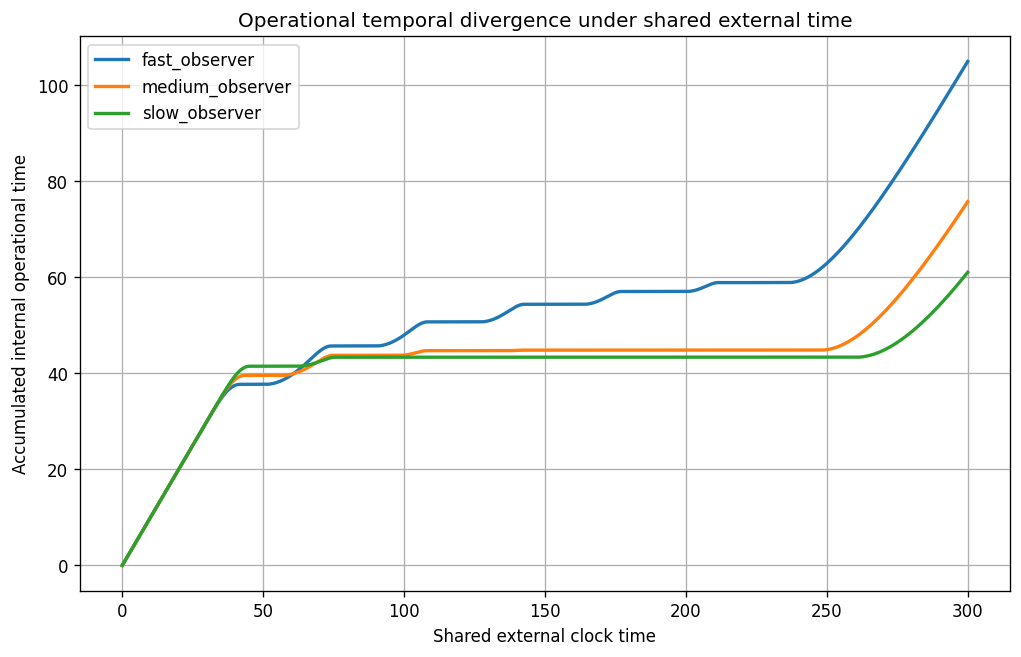

In [16]:
# ==========================================
# 8A. OPERATIONAL INTERNAL TIME
# ==========================================

internal_time_rows = []
for observer_name, params in observers.items():
    r = simulate_observer_multi_pulse(pulses=pulses, tau_r=params["tau_r"], delay=params["delay"], obs_window=params["obs_window"], T=300.0, dt=0.05)
    t = r["t"]
    v = r["v"]
    internal_tau = np.zeros_like(t)
    for i in range(1, len(t)):
        dt_local = t[i] - t[i - 1]
        operational_rate = max(v[i], 0)
        internal_tau[i] = internal_tau[i - 1] + operational_rate * dt_local
    for i in range(len(t)):
        internal_time_rows.append({
            "observer": observer_name,
            "external_time": float(t[i]),
            "v": float(v[i]),
            "internal_operational_time": float(internal_tau[i]),
        })

internal_time_df = pd.DataFrame(internal_time_rows)
save_table(internal_time_df, "internal_operational_time_geometry.csv")

plt.figure(figsize=(10, 6))
for observer_name in observers.keys():
    sub = internal_time_df[internal_time_df["observer"] == observer_name]
    plt.plot(sub["external_time"], sub["internal_operational_time"], label=observer_name, linewidth=2)
plt.xlabel("Shared external clock time")
plt.ylabel("Accumulated internal operational time")
plt.title("Operational temporal divergence under shared external time")
plt.legend()
plt.grid(True)
save_current_fig("operational_internal_time_divergence.png")
plt.show()

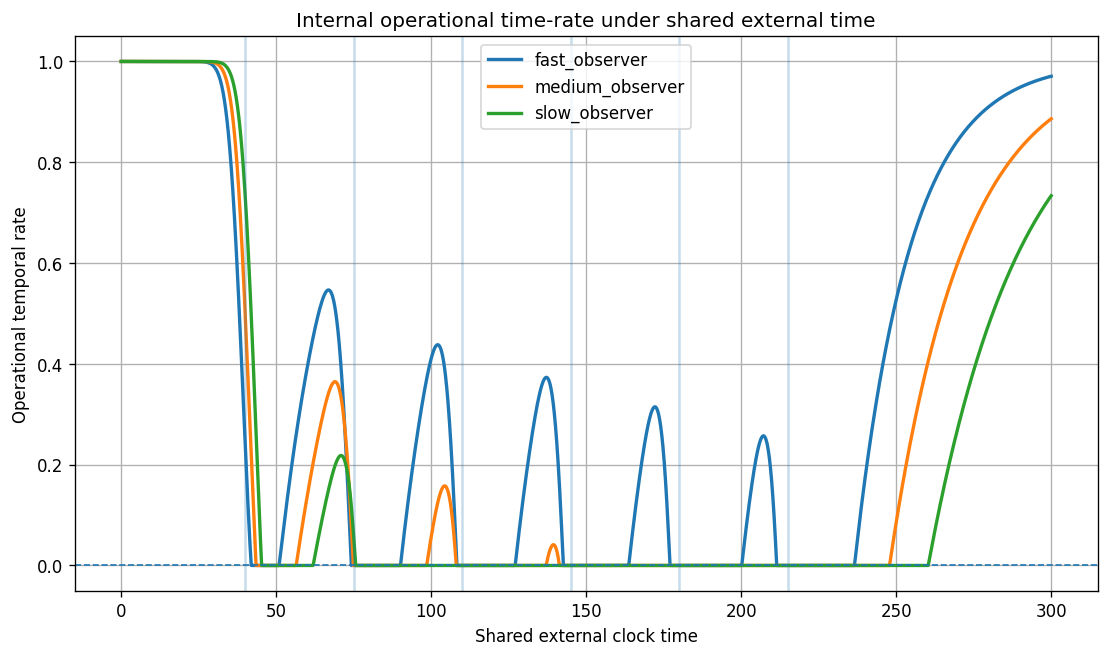

,observer,n_horizon_intervals,total_horizon_time,mean_horizon_duration,max_horizon_duration
0,fast_observer,6,121.05,20.175,26.45
1,medium_observer,3,181.50,60.500,141.60
2,slow_observer,2,205.35,102.675,186.80


In [17]:
# ==========================================
# 8B. OPERATIONAL TEMPORAL RATE AND HORIZONS
# ==========================================

rate_rows = []
for observer_name in observers.keys():
    sub = internal_time_df[internal_time_df["observer"] == observer_name].sort_values("external_time")
    external_time = sub["external_time"].values
    internal_time = sub["internal_operational_time"].values
    operational_rate = np.gradient(internal_time, external_time)
    for t, rate, v in zip(external_time, operational_rate, sub["v"].values):
        rate_rows.append({"observer": observer_name, "external_time": float(t), "v": float(v), "operational_temporal_rate": float(rate)})

operational_rate_df = pd.DataFrame(rate_rows)
save_table(operational_rate_df, "operational_temporal_rate.csv")

plt.figure(figsize=(11, 6))
for observer_name in observers.keys():
    sub = operational_rate_df[operational_rate_df["observer"] == observer_name]
    plt.plot(sub["external_time"], sub["operational_temporal_rate"], label=observer_name, linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
for p in pulses:
    plt.axvline(p["t0"], alpha=0.25)
plt.xlabel("Shared external clock time")
plt.ylabel("Operational temporal rate")
plt.title("Internal operational time-rate under shared external time")
plt.legend()
plt.grid(True)
save_current_fig("operational_temporal_rate.png")
plt.show()

# Horizon detection
rate_threshold = 0.05
horizon_rows = []
for observer_name in observers.keys():
    sub = operational_rate_df[operational_rate_df["observer"] == observer_name].sort_values("external_time")
    frozen = sub["operational_temporal_rate"] <= rate_threshold
    times = sub["external_time"].values
    in_horizon = False
    start_time = None
    for i, is_frozen in enumerate(frozen.values):
        if is_frozen and not in_horizon:
            in_horizon = True
            start_time = times[i]
        if in_horizon and ((not is_frozen) or i == len(frozen.values) - 1):
            end_time = times[i]
            horizon_rows.append({"observer": observer_name, "horizon_start": float(start_time), "horizon_end": float(end_time), "horizon_duration": float(end_time - start_time)})
            in_horizon = False
            start_time = None

horizon_df = pd.DataFrame(horizon_rows)
save_table(horizon_df, "operational_horizon_intervals.csv")

horizon_summary_df = horizon_df.groupby("observer").agg(
    n_horizon_intervals=("horizon_duration", "count"),
    total_horizon_time=("horizon_duration", "sum"),
    mean_horizon_duration=("horizon_duration", "mean"),
    max_horizon_duration=("horizon_duration", "max"),
).reset_index()
save_table(horizon_summary_df, "operational_horizon_summary.csv")
display(horizon_summary_df)

## 9. Temporal accessibility cones

We combine external time, internal operational time, and future accessibility outcomes into a unified operational accessibility representation.

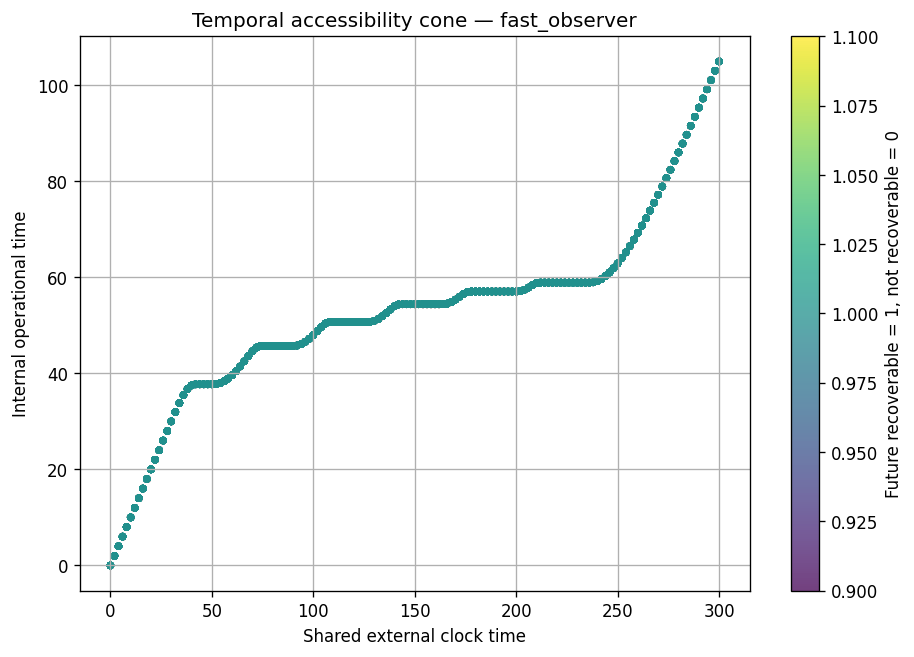

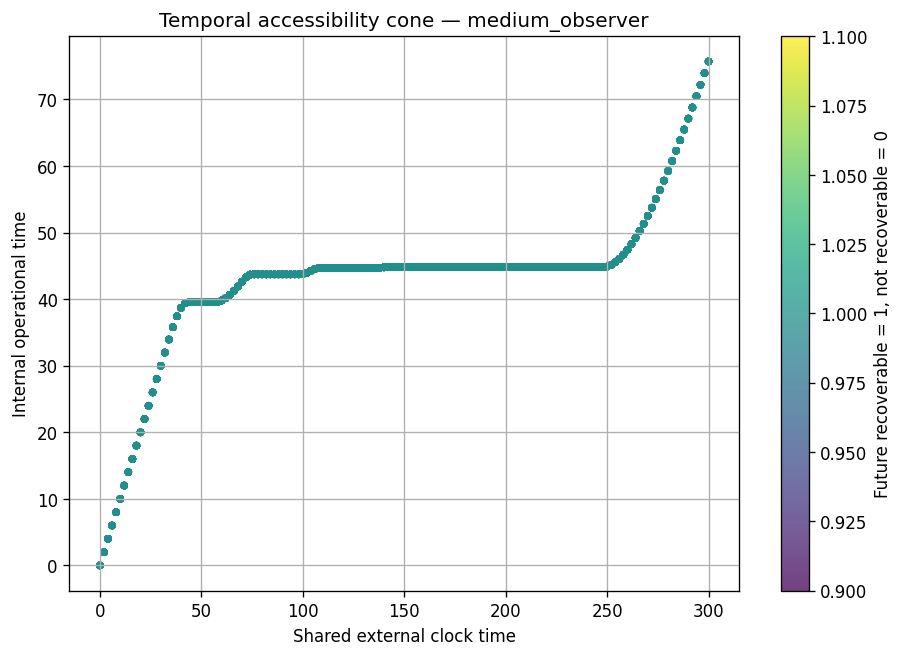

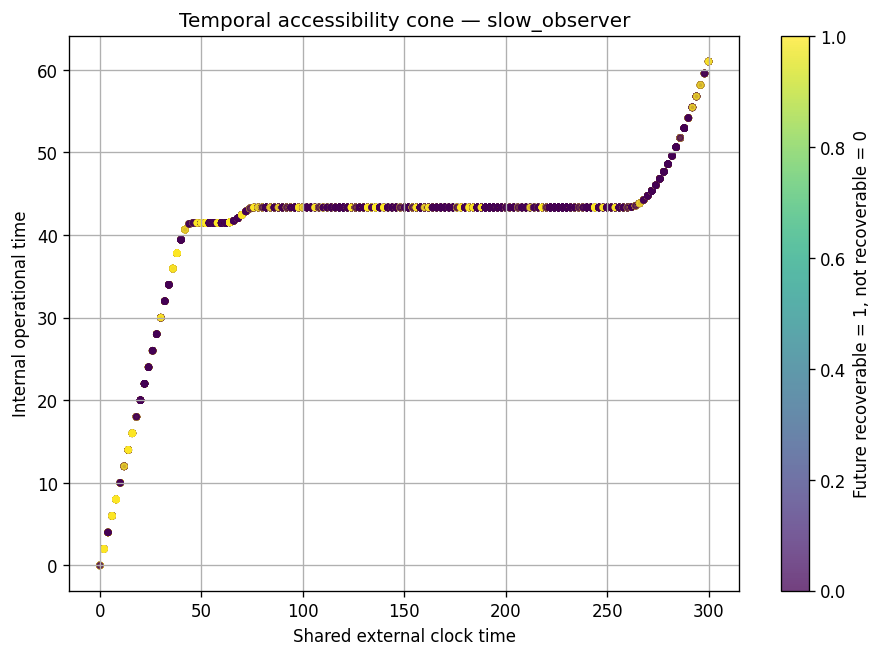

In [18]:
# ==========================================
# 9. TEMPORAL ACCESSIBILITY CONES
# ==========================================

cone_rows = []
for observer_name in observers.keys():
    phase_sub = phase_df[phase_df["observer"] == observer_name].copy().sort_values("current_time")
    internal_sub = internal_time_df[internal_time_df["observer"] == observer_name][["external_time", "internal_operational_time"]].copy().sort_values("external_time")
    merged = pd.merge_asof(phase_sub, internal_sub, left_on="current_time", right_on="external_time", direction="nearest")
    merged["observer"] = observer_name
    cone_rows.append(merged)

cone_df = pd.concat(cone_rows, ignore_index=True)
save_table(cone_df, "temporal_accessibility_cone_dataset.csv")

for observer_name in observers.keys():
    sub = cone_df[cone_df["observer"] == observer_name]
    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(sub["current_time"], sub["internal_operational_time"], c=sub["future_recoverable"].astype(int), s=12, alpha=0.75)
    plt.xlabel("Shared external clock time")
    plt.ylabel("Internal operational time")
    plt.title(f"Temporal accessibility cone — {observer_name}")
    plt.grid(True)
    cbar = plt.colorbar(scatter)
    cbar.set_label("Future recoverable = 1, not recoverable = 0")
    save_current_fig(f"temporal_accessibility_cone_{observer_name}.png")
    plt.show()

## 10. Export publication package

This final section copies all generated tables and figures into publication folders and writes a global inventory plus machine-readable checklists.

In [19]:
# ==========================================
# 10. EXPORT PUBLICATION PACKAGE
# ==========================================

# Copy all generated tables and figures
for file in DATA_DIR.glob("*.csv"):
    shutil.copy2(file, TABLES_FINAL_DIR / file.name)
    shutil.copy2(file, PUBLICATION_DIR / "tables" / file.name)

for file in FIG_DIR.glob("*.png"):
    shutil.copy2(file, FIGURES_FINAL_DIR / file.name)
    shutil.copy2(file, PUBLICATION_DIR / "figures" / file.name)

# Core publication figure list
core_figures = [
    "observer_dependent_recoverability_trajectories.png",
    "future_accessibility_phase_diagram_slow_observer.png",
    "operational_internal_time_divergence.png",
    "operational_temporal_rate.png",
    "accessibility_fragmentation_index_vs_noise.png",
    "temporal_percolation_largest_component_fraction.png",
    "homogeneous_vs_heterogeneous_fragmentation.png",
    "temporal_accessibility_cone_slow_observer.png",
]

core_tables = [
    "observer_recoverability_single_pulse_summary.csv",
    "future_accessibility_phase_diagram.csv",
    "stochastic_robustness_slow_observer_FAST.csv",
    "accessibility_fragmentation_metrics.csv",
    "trajectory_network_geometry_metrics.csv",
    "temporal_percolation_metrics.csv",
    "homogeneous_vs_heterogeneous_temporal_geometry.csv",
    "homogeneous_vs_heterogeneous_summary.csv",
    "internal_operational_time_geometry.csv",
    "operational_temporal_rate.csv",
    "operational_horizon_intervals.csv",
    "operational_horizon_summary.csv",
    "temporal_accessibility_cone_dataset.csv",
]

pd.DataFrame({"required_core_figures": core_figures}).to_csv(PUBLICATION_DIR / "required_core_figures.csv", index=False)
pd.DataFrame({"required_core_tables": core_tables}).to_csv(PUBLICATION_DIR / "required_core_tables.csv", index=False)

# Inventory
inventory = []
for subfolder in ["data", "figures", "tables_final", "figures_final", "publication_package/tables", "publication_package/figures"]:
    folder_path = PROJECT_ROOT / subfolder
    if folder_path.exists():
        for file in folder_path.glob("*"):
            if file.is_file():
                inventory.append({
                    "folder": subfolder,
                    "filename": file.name,
                    "extension": file.suffix,
                    "size_kb": round(file.stat().st_size / 1024, 2),
                    "modified": datetime.fromtimestamp(file.stat().st_mtime).isoformat(),
                })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(PUBLICATION_DIR / "GLOBAL_PROJECT_INVENTORY.csv", index=False)

print("Publication package exported:", PUBLICATION_DIR)
print("Tables:", len(list((PUBLICATION_DIR / 'tables').glob('*.csv'))))
print("Figures:", len(list((PUBLICATION_DIR / 'figures').glob('*.png'))))
display(inventory_df.tail(20))

Publication package exported: /content/publication_package
Tables: 20
Figures: 35


,folder,filename,extension,size_kb,modified
145,publication_package/figures,homogeneous_control_observer_A.png,.png,72.30,2026-05-11T01:29:34.693832
146,publication_package/figures,trajectory_network_connectivity_vs_noise.png,.png,142.67,2026-05-11T01:47:10.108845
147,publication_package/figures,trajectory_network_size_vs_noise.png,.png,135.43,2026-05-11T01:47:09.294759
148,publication_package/figures,dt_robustness_slow_observer_dt_0.02.png,.png,95.27,2026-05-11T01:39:15.012882
149,publication_package/figures,homogeneous_vs_heterogeneous_fragmentation.png,.png,81.71,2026-05-11T01:53:23.955167
150,publication_package/figures,operational_temporal_rate.png,.png,266.89,2026-05-11T01:53:27.214510
151,publication_package/figures,future_accessibility_probe_over_time.png,.png,131.09,2026-05-11T01:29:42.531656
152,publication_package/figures,probe_sigma_robustness_slow_observer_sigma_3.0...,.png,101.13,2026-05-11T01:42:55.707092
153,publication_package/figures,temporal_percolation_largest_component_fractio...,.png,146.63,2026-05-11T01:47:10.908929
154,publication_package/figures,probe_sigma_robustness_slow_observer_sigma_6.0...,.png,101.26,2026-05-11T01:42:57.329263


## 11. Notes for publication

Before release:

1. Restart kernel / runtime.
2. Run all cells from top to bottom.
3. Confirm no Google Drive dependency appears anywhere.
4. Confirm `publication_package/` contains figures, tables, and inventory.
5. Upload repository package to GitHub.
6. Create a Zenodo release to mint DOI.

Recommended manuscript title:

**Recoverability-Constrained Operational Temporal Geometry**